# Time Series Analysis: Trends in Health Indicators and Gender Gaps

This notebook visualizes trends over time for health indicators, gender gaps, and target variables (HALE gap and Life Expectancy gap). It provides comprehensive time series visualizations showing how health patterns have evolved from 2000 to 2019.

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy.stats import linregress

from utils import (
    decorate, underride, configure_plot_style, AIBM_COLORS, 
    code_to_who_country, code_to_wef_country, write_html_table,
    load_and_inventory, compute_gender_gap, summarize_gap, scatter_plot,
    get_oecd, summarize_years, plot_cdfs, plot_distributions,
    column_name_mapping, oecd_codes, load_ihme_indicator
)

configure_plot_style()

# Set maximum year for analysis (excludes 2020+ to avoid COVID-19 distortions)
max_year = 2019
min_year = 2000

## Helper Functions

In [3]:
def load_temporal_data(filename, sex_mapping=None, value_col=None, indicator_type='WHO'):
    """
    Load temporal data for time series analysis, preserving all years.
    
    Parameters
    ----------
    filename : str
        Path to the CSV file
    sex_mapping : dict, optional
        Mapping to convert sex codes to standard names (e.g., {'SEX_MLE': 'Male'})
    value_col : str, optional
        Name of the value column (for IHME data, will be set automatically)
    indicator_type : str
        'WHO' or 'IHME'
        
    Returns
    -------
    df : pandas.DataFrame
        DataFrame with all years preserved, ready for time series analysis
    """
    if indicator_type == 'WHO':
        df, years = load_and_inventory(filename)
        if sex_mapping:
            df['Sex'] = df['Sex'].replace(sex_mapping)
    else:  # IHME - will be loaded separately using load_ihme_indicator
        raise ValueError("For IHME data, use load_ihme_indicator directly")
    
    return df

def compute_temporal_gaps(df, value_col, sexes=['Male', 'Female']):
    """
    Compute gender gaps for all years (not just most recent).
    
    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame with Year, Code, Sex, and value_col columns
    value_col : str
        Name of the value column
    sexes : list
        List of sex values to compare
        
    Returns
    -------
    df_gaps : pandas.DataFrame
        DataFrame with Gap and Mid columns for all years
    """
    return compute_gender_gap(df, value_col, sexes)

## Load Target Variables

### HALE Data

In [4]:
filename = '../data/who_hale_data.csv'
hale, years = load_and_inventory(filename)

(11100, 10)
['SEX_BTSX' 'SEX_FMLE' 'SEX_MLE']
[nan]
[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015 2016 2017 2018 2019]


In [5]:
# Map sex codes to standard names
sex_mapping = {'SEX_BTSX': 'Both', 'SEX_FMLE': 'Female', 'SEX_MLE': 'Male'}
hale['Sex'] = hale['Sex'].replace(sex_mapping)

In [6]:
# Compute gaps for all years (preserve temporal structure)
# Note: compute_gender_gap computes Gap as Male - Female, but we want Female - Male
hale_temporal = compute_temporal_gaps(hale, 'HALE_Years', sexes=['Male', 'Female'])
# Calculate gap as Female - Male (positive gap means women live longer)
# Gap_HALE_Years is Male - Female, so we negate it
hale_temporal['HALE_gap'] = -hale_temporal['Gap_HALE_Years']
hale_temporal.head()

,Code,Year,HALE_Years_Male,HALE_Years_Female,Gap_HALE_Years,Mid_HALE_Years,Country,HALE_gap
0,AFG,2000,45.943669,46.154851,-0.211182,46.049260,Afghanistan,0.211182
1,AFG,2001,45.989073,46.284875,-0.295802,46.136974,Afghanistan,0.295802
2,AFG,2002,47.407615,46.994510,0.413105,47.201063,Afghanistan,-0.413105
3,AFG,2003,48.291904,47.702906,0.588998,47.997405,Afghanistan,-0.588998
4,AFG,2004,48.637754,48.050686,0.587069,48.344220,Afghanistan,-0.587069


### Life Expectancy Data

In [7]:
filename = '../data/who_life_expectancy_data.csv'
le, years = load_and_inventory(filename)

(11100, 10)
['Both sexes' 'Female' 'Male']
[nan]
[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015 2016 2017 2018 2019]


In [8]:
# Map sex codes to standard names
le['Sex'] = le['Sex'].replace(sex_mapping)

In [9]:
# Compute gaps for all years (preserve temporal structure)
# Note: compute_gender_gap computes Gap as Male - Female, but we want Female - Male
le_temporal = compute_temporal_gaps(le, 'LifeExpectancy_Years', sexes=['Male', 'Female'])
# Calculate gap as Female - Male (positive gap means women live longer)
# Gap_LifeExpectancy_Years is Male - Female, so we negate it
le_temporal['LE_gap'] = -le_temporal['Gap_LifeExpectancy_Years']
le_temporal.head()

,Code,Year,LifeExpectancy_Years_Male,LifeExpectancy_Years_Female,Gap_LifeExpectancy_Years,Mid_LifeExpectancy_Years,Country,LE_gap
0,AFG,2000,53.249991,54.429579,-1.179588,53.839785,Afghanistan,1.179588
1,AFG,2001,53.284639,54.570059,-1.285419,53.927349,Afghanistan,1.285419
2,AFG,2002,54.921993,55.401586,-0.479593,55.161789,Afghanistan,0.479593
3,AFG,2003,55.949458,56.242837,-0.293379,56.096147,Afghanistan,0.293379
4,AFG,2004,56.329965,56.647472,-0.317507,56.488719,Afghanistan,0.317507


## Load Predictor Indicators

We'll load all indicators used in the final model. For time series analysis, we need to preserve all years, so we use `compute_temporal_gaps` instead of `summarize_gap`.

### Alcohol Use Disorders (IHME)

In [10]:
def load_ihme_indicator_temporal(base_filename, value_col_name, indicator_code, indicator_name):
    """
    Load IHME indicator data and compute temporal gaps for all years.
    
    Parameters
    ----------
    base_filename : str
        Base filename without path, sex suffix, or extension (e.g., 'ihme_alcohol_use_disorders_deaths')
    value_col_name : str
        Name of the value column (e.g., 'AlcoholUseDisordersDeathRate')
    indicator_code : str
        Indicator code (e.g., 'IHME_ALCOHOL_USE_DISORDERS')
    indicator_name : str
        Human-readable indicator name
        
    Returns
    -------
    df_temporal : pandas.DataFrame
        DataFrame with temporal gaps computed for all years
    """
    filename_male = f'../data/{base_filename}_male.csv'
    filename_female = f'../data/{base_filename}_female.csv'
    df = load_ihme_indicator(
        filename_male, filename_female,
        value_col_name=value_col_name,
        indicator_code=indicator_code,
        indicator_name=indicator_name,
        min_year=min_year,
        max_year=max_year
    )
    df = df.rename(columns=column_name_mapping)
    col = column_name_mapping.get(value_col_name, value_col_name)
    df_temporal = compute_temporal_gaps(df, col, sexes=['Male', 'Female'])
    return df_temporal

alcohol_temporal = load_ihme_indicator_temporal(
    'ihme_alcohol_use_disorders_deaths',
    'AlcoholUseDisordersDeathRate',
    'IHME_ALCOHOL_USE_DISORDERS',
    'Alcohol use disorders, death rate per 100,000'
)
alcohol_temporal.head()

,Code,Year,Alcohol_Male,Alcohol_Female,Gap_Alcohol,Mid_Alcohol,Country
0,AUS,2000.0,2.734867,0.631488,2.103379,1.683177,Australia
1,AUS,2001.0,2.651414,0.616363,2.035051,1.633888,Australia
2,AUS,2002.0,2.712614,0.672539,2.040075,1.692577,Australia
3,AUS,2003.0,2.686314,0.680933,2.005382,1.683623,Australia
4,AUS,2004.0,2.626829,0.704165,1.922664,1.665497,Australia


### Cardiovascular Disease (IHME)

In [11]:
cardiovascular_temporal = load_ihme_indicator_temporal(
    'ihme_cardiovascular_deaths',
    'CardioDeathRate',
    'IHME_CARDIOVASCULAR',
    'Cardiovascular diseases, death rate per 100,000'
)
cardiovascular_temporal.head()

,Code,Year,Cardiovascular_Male,Cardiovascular_Female,Gap_Cardiovascular,Mid_Cardiovascular,Country
0,AUS,2000.0,251.531993,259.494605,-7.962612,255.513299,Australia
1,AUS,2001.0,245.860127,253.477767,-7.617639,249.668947,Australia
2,AUS,2002.0,245.223115,253.122588,-7.899473,249.172852,Australia
3,AUS,2003.0,236.409743,244.429433,-8.019690,240.419588,Australia
4,AUS,2004.0,228.397267,235.278983,-6.881717,231.838125,Australia


### Chronic Respiratory Disease (IHME)

In [12]:
chronic_respiratory_temporal = load_ihme_indicator_temporal(
    'ihme_chronic_respiratory_deaths',
    'ChronicRespiratoryDeathRate',
    'IHME_CHRONIC_RESPIRATORY',
    'Chronic respiratory diseases, death rate per 100,000'
)
chronic_respiratory_temporal.head()

,Code,Year,ChronicRespiratory_Male,ChronicRespiratory_Female,Gap_ChronicRespiratory,Mid_ChronicRespiratory,Country
0,AUS,2000.0,47.317193,33.416935,13.900258,40.367064,Australia
1,AUS,2001.0,46.003680,33.538075,12.465605,39.770878,Australia
2,AUS,2002.0,46.598934,34.771695,11.827239,40.685314,Australia
3,AUS,2003.0,44.267105,34.102959,10.164146,39.185032,Australia
4,AUS,2004.0,42.134910,33.381971,8.752940,37.758441,Australia


### Self-Harm/Suicide (IHME)

In [13]:
self_harm_temporal = load_ihme_indicator_temporal(
    'ihme_self_harm_deaths',
    'SelfHarmDeathRate',
    'IHME_SELF_HARM',
    'Self-harm (suicide), death rate per 100,000'
)
self_harm_temporal.head()

,Code,Year,Suicide_Male,Suicide_Female,Gap_Suicide,Mid_Suicide,Country
0,AUS,2000.0,21.632300,5.627537,16.004763,13.629919,Australia
1,AUS,2001.0,20.813040,5.677859,15.135181,13.245450,Australia
2,AUS,2002.0,19.557416,5.484698,14.072718,12.521057,Australia
3,AUS,2003.0,18.599332,5.150209,13.449123,11.874770,Australia
4,AUS,2004.0,18.148308,4.923421,13.224887,11.535865,Australia


### Interpersonal Violence/Homicide (IHME)

In [14]:
interpersonal_violence_temporal = load_ihme_indicator_temporal(
    'ihme_interpersonal_violence_deaths',
    'InterpersonalViolenceDeathRate',
    'IHME_INTERPERSONAL_VIOLENCE',
    'Interpersonal violence (homicide), death rate per 100,000'
)
interpersonal_violence_temporal.head()

,Code,Year,Homicide_Male,Homicide_Female,Gap_Homicide,Mid_Homicide,Country
0,AUS,2000.0,2.246983,1.220574,1.026409,1.733778,Australia
1,AUS,2001.0,2.213900,1.155846,1.058054,1.684873,Australia
2,AUS,2002.0,2.095225,1.080767,1.014458,1.587996,Australia
3,AUS,2003.0,1.880337,0.889872,0.990465,1.385104,Australia
4,AUS,2004.0,1.495477,0.758536,0.736941,1.127007,Australia


### Road Injuries (IHME)

In [15]:
road_injuries_temporal = load_ihme_indicator_temporal(
    'ihme_road_injuries_deaths',
    'RoadInjuriesDeathRate',
    'IHME_ROAD_INJURIES',
    'Road injuries (road traffic crashes), death rate per 100,000'
)
road_injuries_temporal.head()

,Code,Year,RoadTraffic_Male,RoadTraffic_Female,Gap_RoadTraffic,Mid_RoadTraffic,Country
0,AUS,2000.0,15.184325,6.084094,9.100231,10.634210,Australia
1,AUS,2001.0,14.674288,5.782579,8.891709,10.228433,Australia
2,AUS,2002.0,13.989668,5.545272,8.444396,9.767470,Australia
3,AUS,2003.0,13.230099,5.210589,8.019510,9.220344,Australia
4,AUS,2004.0,12.930886,4.897544,8.033342,8.914215,Australia


### Liver Disease (IHME)

In [16]:
liver_disease_temporal = load_ihme_indicator_temporal(
    'ihme_liver_disease_deaths',
    'LiverDiseaseDeathRate',
    'IHME_LIVER_DISEASE',
    'Cirrhosis and other chronic liver diseases, death rate per 100,000'
)
liver_disease_temporal.head()

,Code,Year,LiverDisease_Male,LiverDisease_Female,Gap_LiverDisease,Mid_LiverDisease,Country
0,AUS,2000.0,9.277966,4.125954,5.152012,6.701960,Australia
1,AUS,2001.0,9.433355,4.028933,5.404421,6.731144,Australia
2,AUS,2002.0,9.887432,4.357130,5.530302,7.122281,Australia
3,AUS,2003.0,10.141958,4.273111,5.868847,7.207535,Australia
4,AUS,2004.0,10.222984,4.275616,5.947368,7.249300,Australia


### Neoplasms (IHME)

In [17]:
neoplasms_temporal = load_ihme_indicator_temporal(
    'ihme_neoplasms_deaths',
    'NeoplasmsDeathRate',
    'IHME_NEOPLASMS',
    'Neoplasms (cancer), death rate per 100,000'
)
neoplasms_temporal.head()

,Code,Year,Neoplasms_Male,Neoplasms_Female,Gap_Neoplasms,Mid_Neoplasms,Country
0,AUS,2000.0,229.808667,174.372594,55.436073,202.090630,Australia
1,AUS,2001.0,230.943004,176.862341,54.080663,203.902673,Australia
2,AUS,2002.0,233.465215,179.519671,53.945544,206.492443,Australia
3,AUS,2003.0,232.827329,178.595845,54.231484,205.711587,Australia
4,AUS,2004.0,233.886844,177.584662,56.302182,205.735753,Australia


### Unintentional Injuries (IHME)

In [18]:
unintentional_injuries_temporal = load_ihme_indicator_temporal(
    'ihme_unintentional_injuries_deaths',
    'UnintentionalInjuriesDeathRate',
    'IHME_UNINTENTIONAL_INJURIES',
    'Unintentional injuries, death rate per 100,000'
)
unintentional_injuries_temporal.head()

,Code,Year,UnintentionalInjury_Male,UnintentionalInjury_Female,Gap_UnintentionalInjury,Mid_UnintentionalInjury,Country
0,AUS,2000.0,14.719270,12.032874,2.686396,13.376072,Australia
1,AUS,2001.0,14.106178,11.824066,2.282112,12.965122,Australia
2,AUS,2002.0,15.206234,12.696670,2.509564,13.951452,Australia
3,AUS,2003.0,15.927738,13.010010,2.917728,14.468874,Australia
4,AUS,2004.0,16.703760,13.977934,2.725826,15.340847,Australia


### Diabetes Type 2 (IHME)

In [19]:
diabetes_temporal = load_ihme_indicator_temporal(
    'ihme_diabetes_deaths',
    'DiabetesDeathRate',
    'IHME_DIABETES_TYPE2',
    'Diabetes mellitus type 2, death rate per 100,000'
)
diabetes_temporal.head()

,Code,Year,Diabetes_Male,Diabetes_Female,Gap_Diabetes,Mid_Diabetes,Country
0,AUS,2000.0,16.568642,14.248627,2.320015,15.408635,Australia
1,AUS,2001.0,17.037716,14.344688,2.693028,15.691202,Australia
2,AUS,2002.0,17.960180,14.975359,2.984820,16.467769,Australia
3,AUS,2003.0,18.379621,15.525666,2.853954,16.952644,Australia
4,AUS,2004.0,18.334611,16.080445,2.254167,17.207528,Australia


## Indicator Statistics Over Time

### Compute Means and Slopes for Each Indicator

In [20]:
def compute_indicator_stats(df_temporal, mid_col, gap_col):
    """
    Compute statistics for each country: mean and slope (trend) over time.
    
    Parameters
    ----------
    df_temporal : pandas.DataFrame
        DataFrame with Year, Code, Country, and value columns
    mid_col : str
        Name of the Mid (rate) column
    gap_col : str
        Name of the Gap column
        
    Returns
    -------
    stats_df : pandas.DataFrame
        DataFrame with Code, Country, and statistics columns
    """
    # Filter to OECD countries
    df = df_temporal.reset_index() if 'Code' in df_temporal.index.names else df_temporal
    df_temp = df.set_index('Code')
    df_oecd = get_oecd(df_temp).reset_index()
    
    stats_list = []
    
    for code in df_oecd['Code'].unique():
        country_data = df_oecd[df_oecd['Code'] == code].copy()
        country_data = country_data.sort_values('Year')
        
        if len(country_data) < 2:
            continue  # Need at least 2 years to compute slope
        
        country_name = country_data['Country'].iloc[0]
        
        # Compute means
        mid_mean = country_data[mid_col].mean()
        gap_mean = country_data[gap_col].mean()
        
        # Compute slopes using linregress
        years = country_data['Year'].values
        mid_values = country_data[mid_col].values
        gap_values = country_data[gap_col].values
        
        mid_slope, _, _, _, _ = linregress(years, mid_values)
        gap_slope, _, _, _, _ = linregress(years, gap_values)
        
        stats_list.append({
            'Code': code,
            'Country': country_name,
            f'{mid_col}_mean': mid_mean,
            f'{mid_col}_slope': mid_slope,
            f'{gap_col}_mean': gap_mean,
            f'{gap_col}_slope': gap_slope
        })
    
    return pd.DataFrame(stats_list)

# Dictionary to store statistics for each indicator
indicator_stats = {}

# Process each indicator
indicators = {
    'Alcohol': (alcohol_temporal, 'Mid_Alcohol', 'Gap_Alcohol'),
    'Cardiovascular': (cardiovascular_temporal, 'Mid_Cardiovascular', 'Gap_Cardiovascular'),
    'ChronicRespiratory': (chronic_respiratory_temporal, 'Mid_ChronicRespiratory', 'Gap_ChronicRespiratory'),
    'Suicide': (self_harm_temporal, 'Mid_Suicide', 'Gap_Suicide'),
    'Homicide': (interpersonal_violence_temporal, 'Mid_Homicide', 'Gap_Homicide'),
    'RoadTraffic': (road_injuries_temporal, 'Mid_RoadTraffic', 'Gap_RoadTraffic'),
    'LiverDisease': (liver_disease_temporal, 'Mid_LiverDisease', 'Gap_LiverDisease'),
    'Neoplasms': (neoplasms_temporal, 'Mid_Neoplasms', 'Gap_Neoplasms'),
    'UnintentionalInjury': (unintentional_injuries_temporal, 'Mid_UnintentionalInjury', 'Gap_UnintentionalInjury'),
    'Diabetes': (diabetes_temporal, 'Mid_Diabetes', 'Gap_Diabetes')
}

for indicator_name, (df_temporal, mid_col, gap_col) in indicators.items():
    stats_df = compute_indicator_stats(df_temporal, mid_col, gap_col)
    indicator_stats[indicator_name] = {
        'stats': stats_df,
        'mid_col': mid_col,
        'gap_col': gap_col
    }

### Create Summary Tables

In [21]:
# Create summary tables for Mid (rates)
mid_summary = []

for indicator_name, data in indicator_stats.items():
    stats_df = data['stats']
    mid_col = data['mid_col']
    
    mid_mean_col = f'{mid_col}_mean'
    mid_slope_col = f'{mid_col}_slope'
    
    # Find countries with extremes
    highest_mean_idx = stats_df[mid_mean_col].idxmax()
    lowest_mean_idx = stats_df[mid_mean_col].idxmin()
    highest_slope_idx = stats_df[mid_slope_col].idxmax()
    lowest_slope_idx = stats_df[mid_slope_col].idxmin()
    
    mid_summary.append({
        'Indicator': indicator_name,
        'Highest Mean Country': stats_df.loc[highest_mean_idx, 'Country'],
        'Highest Mean Value': stats_df.loc[highest_mean_idx, mid_mean_col],
        'Lowest Mean Country': stats_df.loc[lowest_mean_idx, 'Country'],
        'Lowest Mean Value': stats_df.loc[lowest_mean_idx, mid_mean_col],
        'Highest Slope Country': stats_df.loc[highest_slope_idx, 'Country'],
        'Highest Slope Value': stats_df.loc[highest_slope_idx, mid_slope_col],
        'Lowest Slope Country': stats_df.loc[lowest_slope_idx, 'Country'],
        'Lowest Slope Value': stats_df.loc[lowest_slope_idx, mid_slope_col]
    })

mid_summary_df = pd.DataFrame(mid_summary)
mid_summary_df

,Indicator,Highest Mean Country,Highest Mean Value,Lowest Mean Country,Lowest Mean Value,Highest Slope Country,Highest Slope Value,Lowest Slope Country,Lowest Slope Value
0,Alcohol,Estonia,19.706061,Colombia,0.195838,Slovenia,0.340501,Estonia,-0.889445
1,Cardiovascular,Latvia,784.312956,Mexico,108.320813,Lithuania,8.350094,Estonia,-11.125299
2,ChronicRespiratory,Denmark,78.922716,Latvia,17.170754,Hungary,1.516302,Lithuania,-0.506960
3,Suicide,Lithuania,41.692474,Türkiye,2.708351,South Korea,0.352210,Lithuania,-0.977161
4,Homicide,Colombia,46.185399,Japan,0.634340,Mexico,1.001632,Colombia,-2.907667
5,RoadTraffic,Lithuania,17.485875,Sweden,4.442770,Costa Rica,0.001071,Latvia,-1.060943
6,LiverDisease,Hungary,48.955899,Iceland,3.274608,Lithuania,0.394078,Hungary,-1.854284
7,Neoplasms,Hungary,341.509059,Mexico,69.054896,Japan,5.687213,Luxembourg,-2.020555
8,UnintentionalInjury,Lithuania,57.092661,Türkiye,11.940124,Netherlands,1.040001,Estonia,-2.353193
9,Diabetes,Mexico,44.137805,Japan,6.427513,Czechia,1.712105,Israel,-0.786123


In [22]:
# Create summary table for Gap (gaps)
gap_summary = []

for indicator_name, data in indicator_stats.items():
    stats_df = data['stats']
    gap_col = data['gap_col']
    
    gap_mean_col = f'{gap_col}_mean'
    gap_slope_col = f'{gap_col}_slope'
    
    # Find countries with extremes
    highest_mean_idx = stats_df[gap_mean_col].idxmax()
    lowest_mean_idx = stats_df[gap_mean_col].idxmin()
    highest_slope_idx = stats_df[gap_slope_col].idxmax()
    lowest_slope_idx = stats_df[gap_slope_col].idxmin()
    
    gap_summary.append({
        'Indicator': indicator_name,
        'Highest Mean Country': stats_df.loc[highest_mean_idx, 'Country'],
        'Highest Mean Value': stats_df.loc[highest_mean_idx, gap_mean_col],
        'Lowest Mean Country': stats_df.loc[lowest_mean_idx, 'Country'],
        'Lowest Mean Value': stats_df.loc[lowest_mean_idx, gap_mean_col],
        'Highest Slope Country': stats_df.loc[highest_slope_idx, 'Country'],
        'Highest Slope Value': stats_df.loc[highest_slope_idx, gap_slope_col],
        'Lowest Slope Country': stats_df.loc[lowest_slope_idx, 'Country'],
        'Lowest Slope Value': stats_df.loc[lowest_slope_idx, gap_slope_col]
    })

gap_summary_df = pd.DataFrame(gap_summary)
gap_summary_df

,Indicator,Highest Mean Country,Highest Mean Value,Lowest Mean Country,Lowest Mean Value,Highest Slope Country,Highest Slope Value,Lowest Slope Country,Lowest Slope Value
0,Alcohol,Estonia,25.313298,Colombia,0.297476,Slovenia,0.595594,Estonia,-0.899777
1,Cardiovascular,Costa Rica,22.898089,Austria,-94.884899,Germany,4.621782,Lithuania,-4.214991
2,ChronicRespiratory,Spain,35.335753,Iceland,-12.166528,Japan,0.856533,Belgium,-1.206438
3,Suicide,Lithuania,57.499107,Türkiye,2.865538,South Korea,0.467148,Lithuania,-1.345167
4,Homicide,Colombia,75.347633,Switzerland,0.057507,Mexico,1.585338,Colombia,-4.690662
5,RoadTraffic,Costa Rica,21.123579,Iceland,3.069028,Colombia,0.140004,Latvia,-1.222436
6,LiverDisease,Hungary,44.925174,Iceland,1.071080,Lithuania,0.458676,Hungary,-1.876770
7,Neoplasms,Japan,128.964356,Mexico,0.609135,Portugal,1.859587,Hungary,-2.092135
8,UnintentionalInjury,Lithuania,63.253265,Netherlands,-6.435005,Denmark,0.233644,Estonia,-3.288153
9,Diabetes,Denmark,3.543913,Portugal,-8.273666,Germany,0.544288,South Korea,-0.343110


In [23]:
# Export summary tables to HTML
write_html_table(mid_summary_df, 'jb/tables/indicator_rates_summary_timeseries.html')
write_html_table(gap_summary_df, 'jb/tables/indicator_gaps_summary_timeseries.html')

## Target Variable Time Series

### HALE Gap Time Series

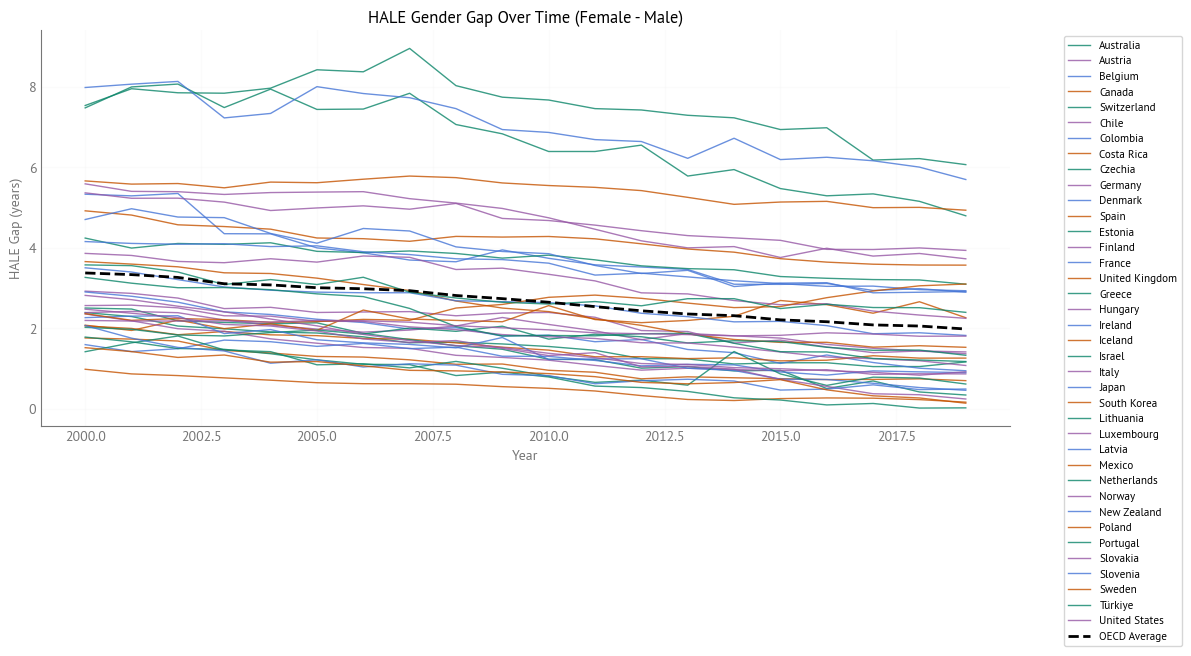

In [24]:
def plot_gap_timeseries(df, gap_col, countries=None, oecd_avg=True, title=None, ylabel=None):
    """
    Plot gap time series for selected countries and OECD average.
    
    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame with Year, Code, Country, and gap_col columns
    gap_col : str
        Name of the gap column to plot
    countries : list, optional
        List of country codes to plot. If None, plots all OECD countries.
    oecd_avg : bool
        Whether to include OECD average line
    title : str, optional
        Plot title
    ylabel : str, optional
        Y-axis label
    """
    # Filter to OECD countries
    # get_oecd expects Code as index, so set it temporarily
    df = df.reset_index() if 'Code' in df.index.names else df
    df_temp = df.set_index('Code')
    df_oecd = get_oecd(df_temp).reset_index()
    
    # Filter to countries of interest
    if countries is None:
        countries = df_oecd['Code'].unique()
    
    df_plot = df_oecd[df_oecd['Code'].isin(countries)].copy()
    
    # Create figure
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Plot individual countries
    for code in countries:
        country_data = df_plot[df_plot['Code'] == code]
        if not country_data.empty:
            country_name = country_data['Country'].iloc[0]
            ax.plot(country_data['Year'], country_data[gap_col], 
                   alpha=0.8, linewidth=1, label=country_name)
    
    # Plot OECD average
    if oecd_avg:
        oecd_avg_by_year = df_plot.groupby('Year')[gap_col].mean()
        ax.plot(oecd_avg_by_year.index, oecd_avg_by_year.values,
               color='black', linewidth=2, linestyle='--', label='OECD Average')
    
    # Formatting
    ax.set_xlabel('Year')
    ax.set_ylabel(ylabel or gap_col)
    ax.set_title(title or f'{gap_col} Over Time')
    ax.grid(True, alpha=0.3)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    
    plt.tight_layout()
    return fig, ax

def plot_rate_timeseries(df, rate_col, countries=None, oecd_avg=True, title=None, ylabel=None):
    """
    Plot rate time series for selected countries and OECD average.
    
    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame with Year, Code, Country, and rate_col columns
    rate_col : str
        Name of the rate column to plot
    countries : list, optional
        List of country codes to plot. If None, plots all OECD countries.
    oecd_avg : bool
        Whether to include OECD average line
    title : str, optional
        Plot title
    ylabel : str, optional
        Y-axis label
    """
    # Filter to OECD countries
    df = df.reset_index() if 'Code' in df.index.names else df
    df_temp = df.set_index('Code')
    df_oecd = get_oecd(df_temp).reset_index()
    
    # Filter to countries of interest
    if countries is None:
        countries = df_oecd['Code'].unique()
    
    df_plot = df_oecd[df_oecd['Code'].isin(countries)].copy()
    
    # Create figure
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Plot individual countries
    for code in countries:
        country_data = df_plot[df_plot['Code'] == code]
        if not country_data.empty:
            country_name = country_data['Country'].iloc[0]
            ax.plot(country_data['Year'], country_data[rate_col], 
                   alpha=0.8, linewidth=1, label=country_name)
    
    # Plot OECD average
    if oecd_avg:
        oecd_avg_by_year = df_plot.groupby('Year')[rate_col].mean()
        ax.plot(oecd_avg_by_year.index, oecd_avg_by_year.values,
               color='black', linewidth=2, linestyle='--', label='OECD Average')
    
    # Formatting
    ax.set_xlabel('Year')
    ax.set_ylabel(ylabel or rate_col)
    ax.set_title(title or f'{rate_col} Over Time')
    ax.grid(True, alpha=0.3)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    
    plt.tight_layout()
    return fig, ax

# Plot HALE gap time series for all OECD countries
fig, ax = plot_gap_timeseries(
    hale_temporal.reset_index(),
    'HALE_gap',
    title='HALE Gender Gap Over Time (Female - Male)',
    ylabel='HALE Gap (years)'
)
plt.savefig('jb/figs/hale_gap_timeseries_all.png', dpi=150, bbox_inches='tight')
plt.show()

### Life Expectancy Gap Time Series

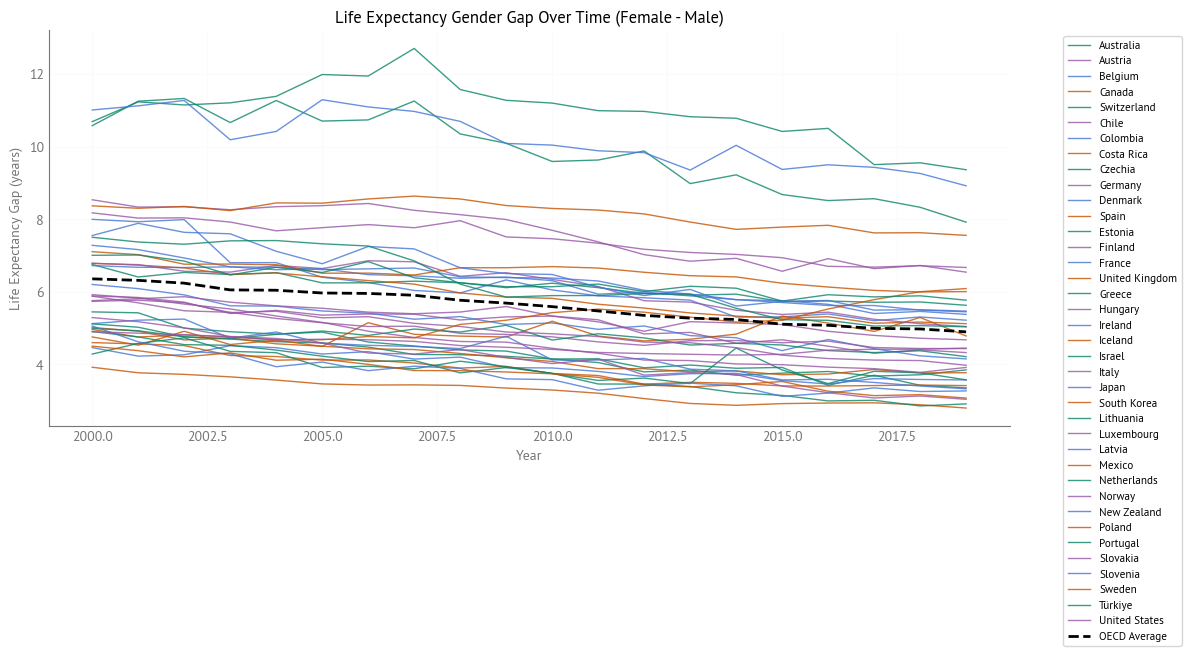

In [25]:
# Plot Life Expectancy gap time series for all OECD countries
fig, ax = plot_gap_timeseries(
    le_temporal.reset_index(),
    'LE_gap',
    title='Life Expectancy Gender Gap Over Time (Female - Male)',
    ylabel='Life Expectancy Gap (years)'
)
plt.savefig('jb/figs/le_gap_timeseries_all.png', dpi=150, bbox_inches='tight')
plt.show()

### HALE Gap: Selected Countries

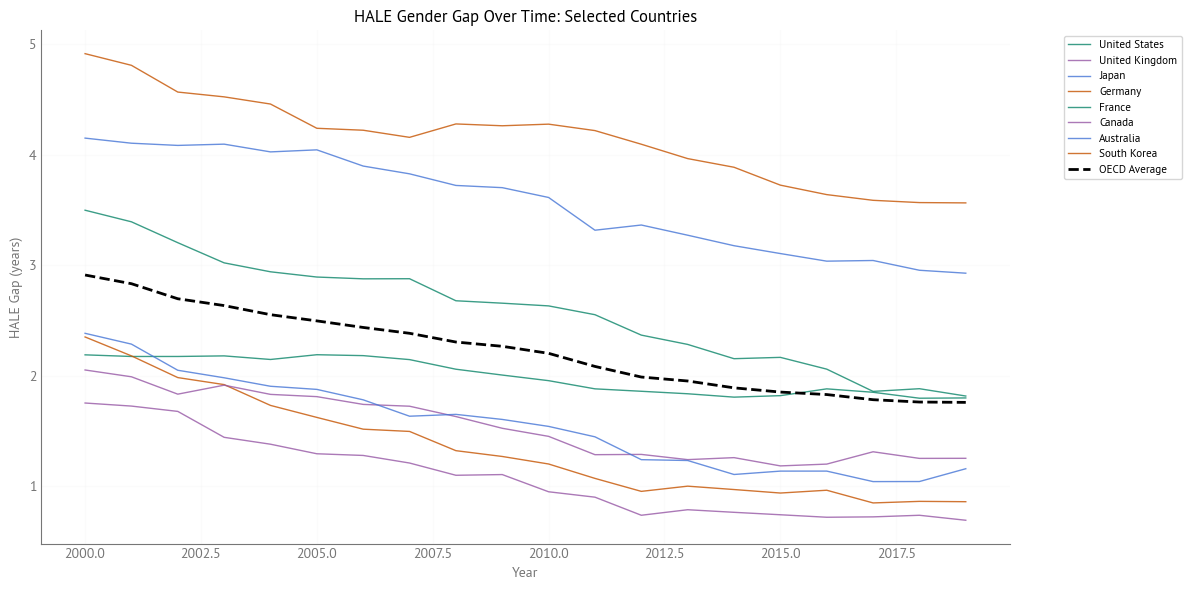

In [26]:
# Plot HALE gap for selected countries of interest
selected_countries = ['USA', 'GBR', 'JPN', 'DEU', 'FRA', 'CAN', 'AUS', 'KOR']
fig, ax = plot_gap_timeseries(
    hale_temporal.reset_index(),
    'HALE_gap',
    countries=selected_countries,
    title='HALE Gender Gap Over Time: Selected Countries',
    ylabel='HALE Gap (years)'
)
plt.savefig('jb/figs/hale_gap_timeseries_selected.png', dpi=150, bbox_inches='tight')
plt.show()

### Life Expectancy Gap: Selected Countries

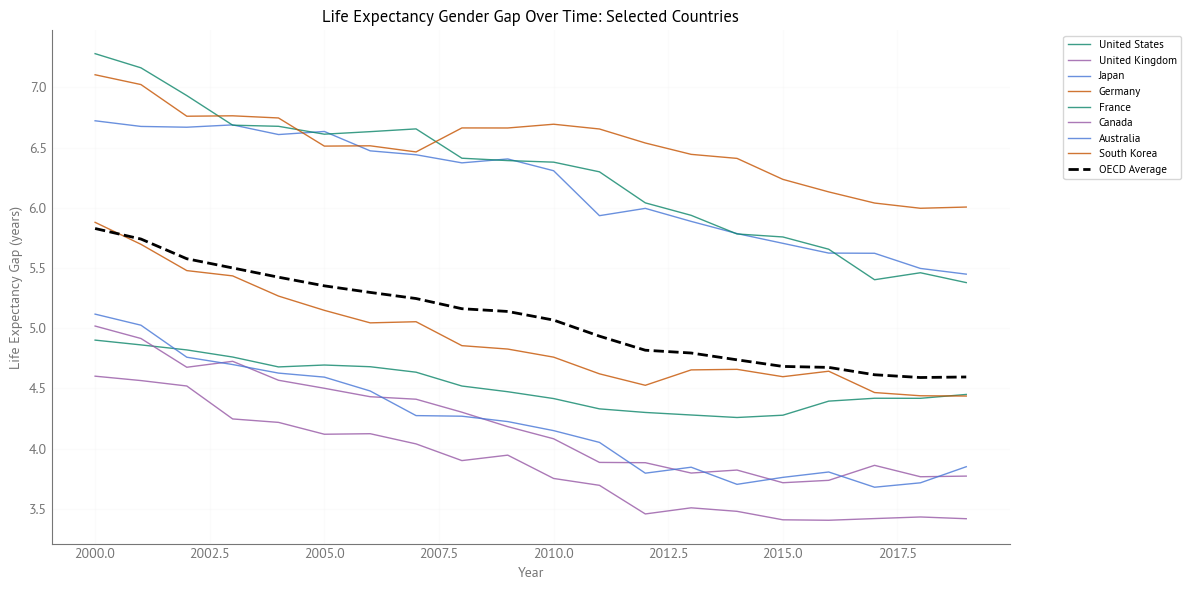

In [27]:
# Plot Life Expectancy gap for selected countries
fig, ax = plot_gap_timeseries(
    le_temporal.reset_index(),
    'LE_gap',
    countries=selected_countries,
    title='Life Expectancy Gender Gap Over Time: Selected Countries',
    ylabel='Life Expectancy Gap (years)'
)
plt.savefig('jb/figs/le_gap_timeseries_selected.png', dpi=150, bbox_inches='tight')
plt.show()

### HALE Time Series (Overall Rates)

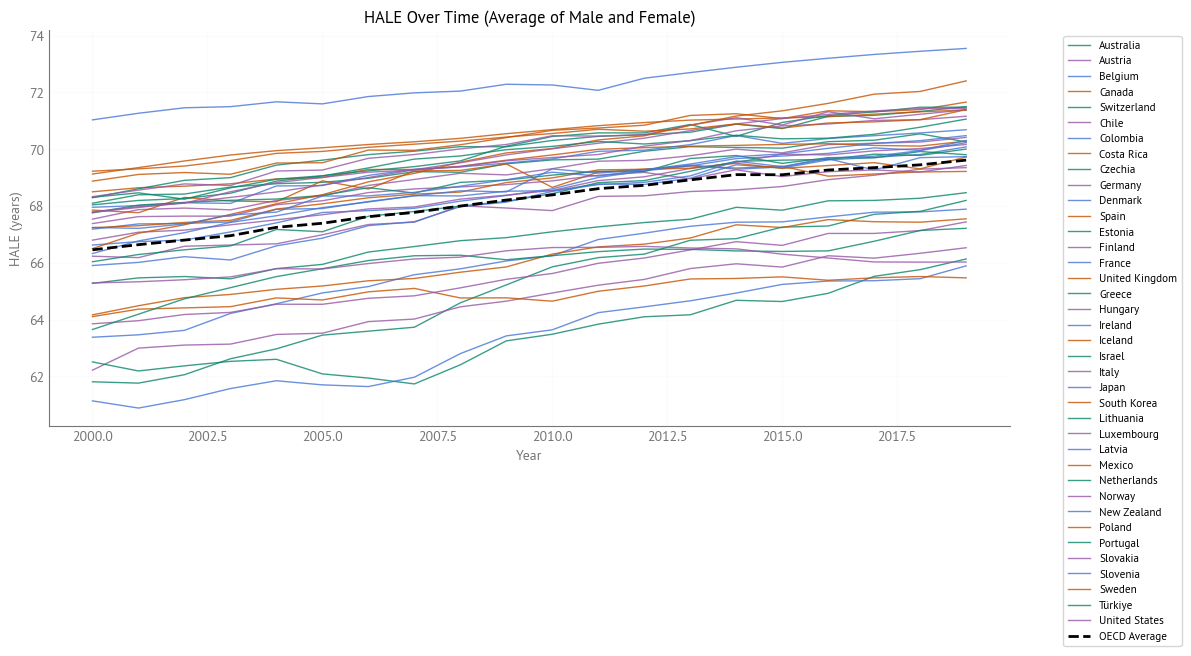

In [28]:
# Plot HALE (midpoint) time series for all OECD countries
fig, ax = plot_rate_timeseries(
    hale_temporal.reset_index(),
    'Mid_HALE_Years',
    title='HALE Over Time (Average of Male and Female)',
    ylabel='HALE (years)'
)
plt.savefig('jb/figs/hale_timeseries_all.png', dpi=150, bbox_inches='tight')
plt.show()

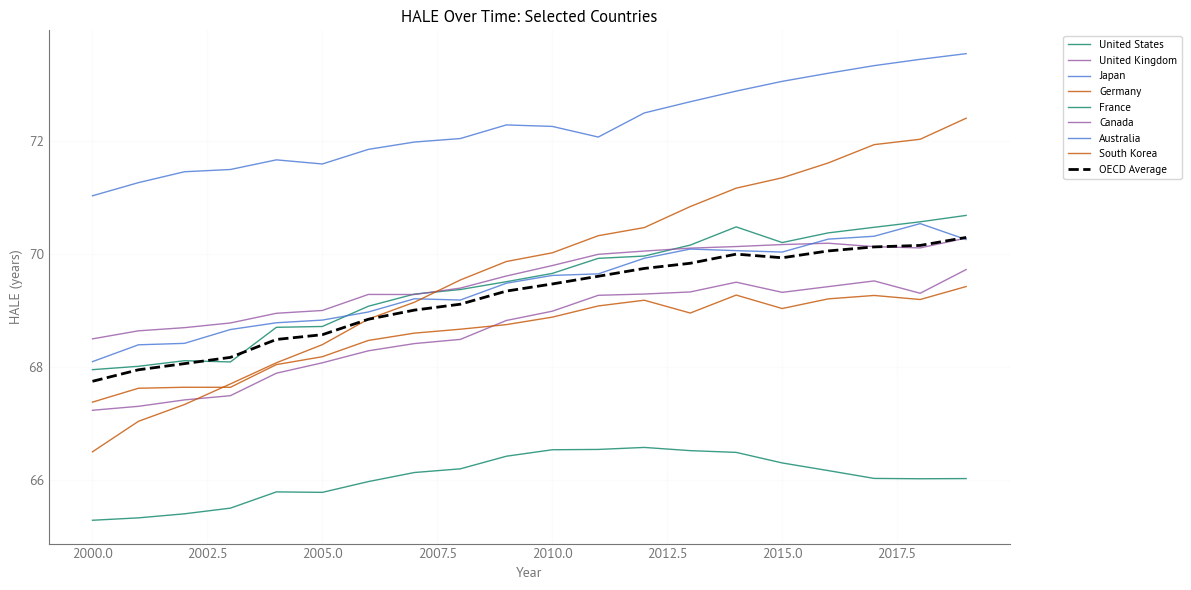

In [29]:
# Plot HALE for selected countries
fig, ax = plot_rate_timeseries(
    hale_temporal.reset_index(),
    'Mid_HALE_Years',
    countries=selected_countries,
    title='HALE Over Time: Selected Countries',
    ylabel='HALE (years)'
)
plt.savefig('jb/figs/hale_timeseries_selected.png', dpi=150, bbox_inches='tight')
plt.show()

### Life Expectancy Time Series (Overall Rates)

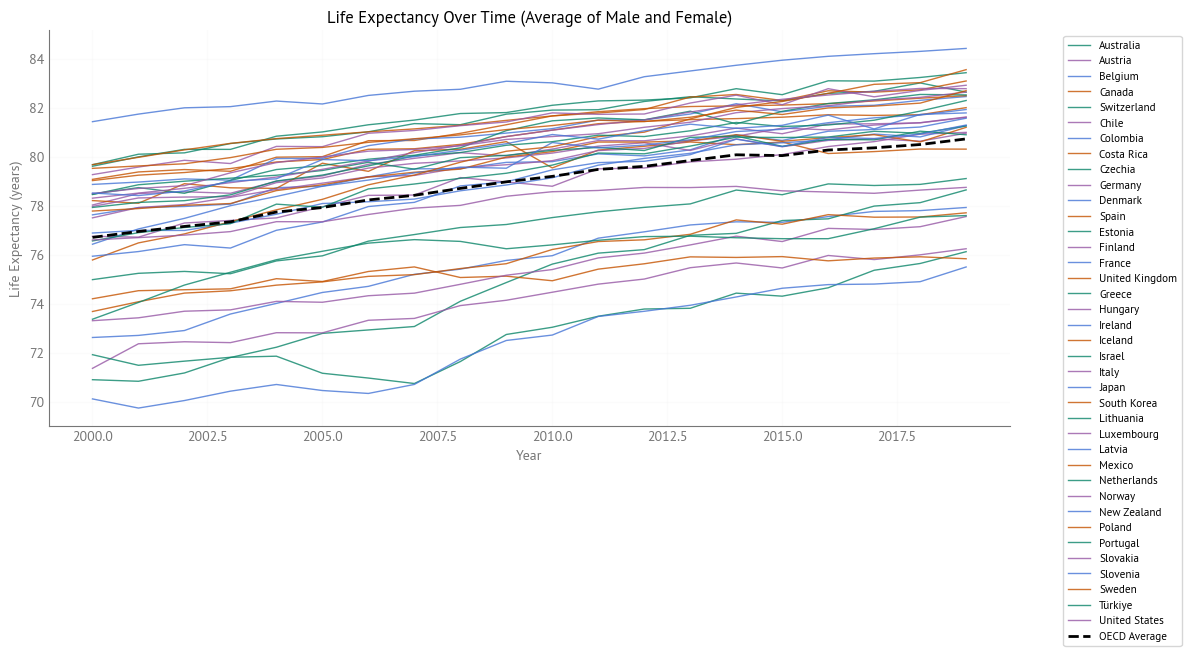

In [30]:
# Plot Life Expectancy (midpoint) time series for all OECD countries
fig, ax = plot_rate_timeseries(
    le_temporal.reset_index(),
    'Mid_LifeExpectancy_Years',
    title='Life Expectancy Over Time (Average of Male and Female)',
    ylabel='Life Expectancy (years)'
)
plt.savefig('jb/figs/le_timeseries_all.png', dpi=150, bbox_inches='tight')
plt.show()

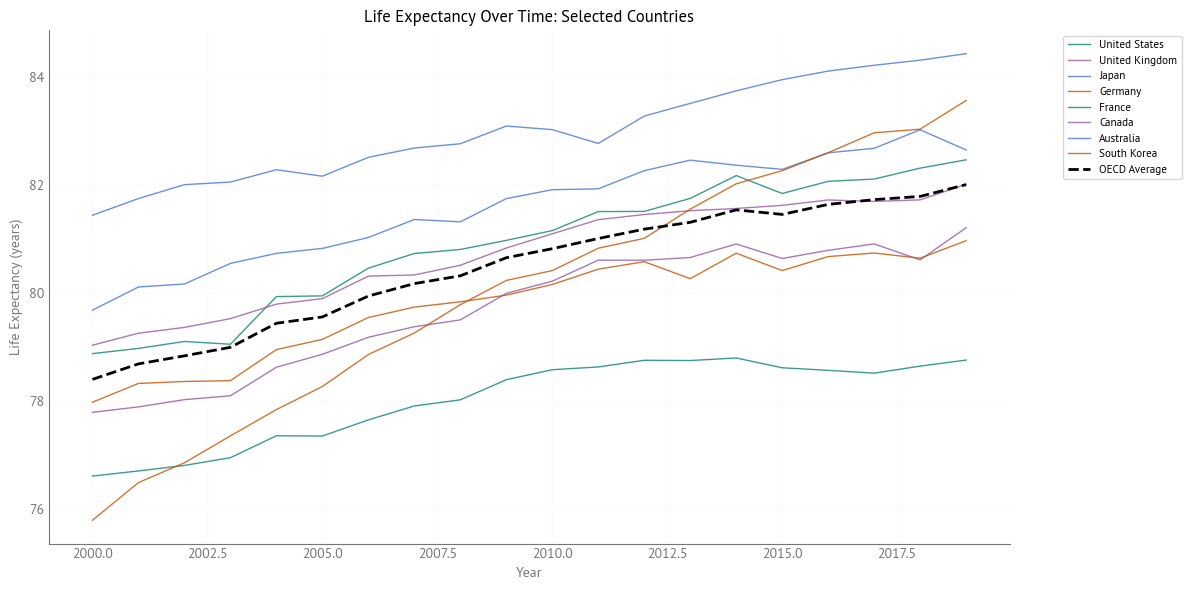

In [31]:
# Plot Life Expectancy for selected countries
fig, ax = plot_rate_timeseries(
    le_temporal.reset_index(),
    'Mid_LifeExpectancy_Years',
    countries=selected_countries,
    title='Life Expectancy Over Time: Selected Countries',
    ylabel='Life Expectancy (years)'
)
plt.savefig('jb/figs/le_timeseries_selected.png', dpi=150, bbox_inches='tight')
plt.show()

### Gap Changes Summary Table

In [32]:
def compute_gap_changes(df, gap_col, year_start=2000, year_end=2019):
    """
    Compute gap changes from start to end year for each country.
    
    Returns DataFrame with Country, gap_start, gap_end, change, and pct_change.
    """
    # get_oecd expects Code as index, so set it temporarily
    df = df.reset_index() if 'Code' in df.index.names else df
    df_temp = df.set_index('Code')
    df_oecd = get_oecd(df_temp).reset_index()
    
    # Get data for start and end years
    start_data = df_oecd[df_oecd['Year'] == year_start][['Code', 'Country', gap_col]].copy()
    end_data = df_oecd[df_oecd['Year'] == year_end][['Code', 'Country', gap_col]].copy()
    
    # Merge
    changes = start_data.merge(end_data, on=['Code', 'Country'], suffixes=('_start', '_end'))
    changes['change'] = changes[f'{gap_col}_end'] - changes[f'{gap_col}_start']
    changes['pct_change'] = (changes['change'] / changes[f'{gap_col}_start'].abs()) * 100
    
    # Sort by 2019 gap value (descending)
    changes = changes.sort_values(f'{gap_col}_end', ascending=False)
    
    return changes

# Compute HALE gap changes
hale_changes = compute_gap_changes(hale_temporal.reset_index(), 'HALE_gap')
hale_changes[['Country', 'HALE_gap_start', 'HALE_gap_end', 'change']]

,Country,HALE_gap_start,HALE_gap_end,change
24,Lithuania,7.531095,6.062020,-1.469075
26,Latvia,7.978349,5.691968,-2.286380
31,Poland,5.657452,4.929800,-0.727652
12,Estonia,7.471845,4.790534,-2.681311
33,Slovakia,5.361061,3.930964,-1.430097
17,Hungary,5.584386,3.722175,-1.862211
23,South Korea,4.914148,3.564595,-1.349552
27,Mexico,2.358668,3.095419,0.736751
8,Czechia,4.237001,3.091037,-1.145964
22,Japan,4.150422,2.928847,-1.221575


In [33]:
# Compute Life Expectancy gap changes
le_changes = compute_gap_changes(le_temporal.reset_index(), 'LE_gap')
le_changes[['Country', 'LE_gap_start', 'LE_gap_end', 'change']]

,Country,LE_gap_start,LE_gap_end,change
24,Lithuania,10.686971,9.361672,-1.325298
26,Latvia,11.008141,8.919780,-2.088361
12,Estonia,10.575938,7.918789,-2.657149
31,Poland,8.367967,7.554684,-0.813283
33,Slovakia,8.174914,6.670498,-1.504416
17,Hungary,8.535396,6.541844,-1.993552
27,Mexico,4.962907,6.090152,1.127244
23,South Korea,7.105341,6.006658,-1.098682
32,Portugal,7.006117,5.770625,-1.235492
8,Czechia,6.753530,5.629791,-1.123738


In [34]:
# Export gap changes to HTML table
hale_changes_display = hale_changes[['Country', 'HALE_gap_start', 'HALE_gap_end', 'change']].copy()
hale_changes_display.columns = ['Country', 'Gap 2000', 'Gap 2019', 'Change']
hale_changes_display = hale_changes_display.round(2)
write_html_table(hale_changes_display, 'jb/tables/hale_gap_changes_2000_2019.html')

le_changes_display = le_changes[['Country', 'LE_gap_start', 'LE_gap_end', 'change']].copy()
le_changes_display.columns = ['Country', 'Gap 2000', 'Gap 2019', 'Change']
le_changes_display = le_changes_display.round(2)
write_html_table(le_changes_display, 'jb/tables/le_gap_changes_2000_2019.html')

### HALE and Life Expectancy Value Changes

In [35]:
def compute_value_changes(df, value_col, year_start=2000, year_end=2019):
    """
    Compute value changes from start to end year for each country.
    
    Returns DataFrame with Country, value_start, value_end, change, and pct_change.
    """
    # get_oecd expects Code as index, so set it temporarily
    df = df.reset_index() if 'Code' in df.index.names else df
    df_temp = df.set_index('Code')
    df_oecd = get_oecd(df_temp).reset_index()
    
    # Get data for start and end years
    start_data = df_oecd[df_oecd['Year'] == year_start][['Code', 'Country', value_col]].copy()
    end_data = df_oecd[df_oecd['Year'] == year_end][['Code', 'Country', value_col]].copy()
    
    # Merge
    changes = start_data.merge(end_data, on=['Code', 'Country'], suffixes=('_start', '_end'))
    changes['change'] = changes[f'{value_col}_end'] - changes[f'{value_col}_start']
    changes['pct_change'] = (changes['change'] / changes[f'{value_col}_start']) * 100
    
    # Sort by 2019 value (descending)
    changes = changes.sort_values(f'{value_col}_end', ascending=False)
    
    return changes

# Compute HALE value changes
hale_value_changes = compute_value_changes(hale_temporal.reset_index(), 'Mid_HALE_Years')
hale_value_changes[['Country', 'Mid_HALE_Years_start', 'Mid_HALE_Years_end', 'change']]

,Country,Mid_HALE_Years_start,Mid_HALE_Years_end,change
22,Japan,71.033493,73.549538,2.516045
23,South Korea,66.501516,72.406628,5.905112
11,Spain,68.876392,71.658976,2.782584
4,Switzerland,68.291606,71.499702,3.208097
20,Israel,68.308333,71.479716,3.171383
25,Luxembourg,67.777964,71.432871,3.654907
35,Sweden,69.226121,71.394316,2.168195
21,Italy,68.328524,71.387897,3.059373
19,Iceland,69.126813,71.382149,2.255336
29,Norway,67.795719,71.162035,3.366316


In [36]:
# Compute Life Expectancy value changes
le_value_changes = compute_value_changes(le_temporal.reset_index(), 'Mid_LifeExpectancy_Years')
le_value_changes[['Country', 'Mid_LifeExpectancy_Years_start', 'Mid_LifeExpectancy_Years_end', 'change']]

,Country,Mid_LifeExpectancy_Years_start,Mid_LifeExpectancy_Years_end,change
22,Japan,81.438448,84.427418,2.988970
23,South Korea,75.795748,83.561308,7.765560
4,Switzerland,79.619797,83.437372,3.817576
11,Spain,79.085362,83.098880,4.013518
21,Italy,79.278175,82.924904,3.646729
25,Luxembourg,78.317636,82.785728,4.468092
35,Sweden,79.533942,82.705263,3.171320
0,Australia,79.682270,82.645943,2.963673
29,Norway,78.506744,82.643949,4.137205
20,Israel,78.483514,82.531441,4.047927


In [37]:
# Export value changes to HTML table
hale_value_changes_display = hale_value_changes[['Country', 'Mid_HALE_Years_start', 'Mid_HALE_Years_end', 'change']].copy()
hale_value_changes_display.columns = ['Country', 'HALE 2000', 'HALE 2019', 'Change']
hale_value_changes_display = hale_value_changes_display.round(2)
write_html_table(hale_value_changes_display, 'jb/tables/hale_value_changes_2000_2019.html')

le_value_changes_display = le_value_changes[['Country', 'Mid_LifeExpectancy_Years_start', 'Mid_LifeExpectancy_Years_end', 'change']].copy()
le_value_changes_display.columns = ['Country', 'Life Expectancy 2000', 'Life Expectancy 2019', 'Change']
le_value_changes_display = le_value_changes_display.round(2)
write_html_table(le_value_changes_display, 'jb/tables/le_value_changes_2000_2019.html')

## Target Variable Statistics: HALE and Life Expectancy

### Compute Statistics for HALE and LE

In [38]:
def compute_target_stats(df_temporal, value_col):
    """
    Compute statistics for each country: mean and slope (trend) over time.
    
    Parameters
    ----------
    df_temporal : pandas.DataFrame
        DataFrame with Year, Code, Country, and value column
    value_col : str
        Name of the value column to analyze
        
    Returns
    -------
    stats_df : pandas.DataFrame
        DataFrame with Code, Country, mean, and slope columns
    """
    # Filter to OECD countries
    df = df_temporal.reset_index() if 'Code' in df_temporal.index.names else df_temporal
    df_temp = df.set_index('Code')
    df_oecd = get_oecd(df_temp).reset_index()
    
    stats_list = []
    
    for code in df_oecd['Code'].unique():
        country_data = df_oecd[df_oecd['Code'] == code].copy()
        country_data = country_data.sort_values('Year')
        
        if len(country_data) < 2:
            continue  # Need at least 2 years to compute slope
        
        country_name = country_data['Country'].iloc[0]
        
        # Compute mean
        mean_value = country_data[value_col].mean()
        
        # Compute slope using linregress
        years = country_data['Year'].values
        values = country_data[value_col].values
        
        slope, _, _, _, _ = linregress(years, values)
        
        stats_list.append({
            'Code': code,
            'Country': country_name,
            'Mean': mean_value,
            'Slope': slope
        })
    
    return pd.DataFrame(stats_list)

# Compute statistics for HALE
hale_stats = compute_target_stats(hale_temporal.reset_index(), 'Mid_HALE_Years')
hale_stats.head()

,Code,Country,Mean,Slope
0,AUS,Australia,69.441807,0.123705
1,AUT,Austria,69.142580,0.153927
2,BEL,Belgium,68.582517,0.149442
3,CAN,Canada,69.557660,0.100640
4,CHE,Switzerland,70.121829,0.154044


In [39]:
# Compute statistics for Life Expectancy
le_stats = compute_target_stats(le_temporal.reset_index(), 'Mid_LifeExpectancy_Years')
le_stats.head()

,Code,Country,Mean,Slope
0,AUS,Australia,81.582836,0.163509
1,AUT,Austria,80.102657,0.186219
2,BEL,Belgium,79.699272,0.202118
3,CAN,Canada,80.730940,0.160871
4,CHE,Switzerland,81.791576,0.190887


In [40]:
# Compute statistics for HALE gap
hale_gap_stats = compute_target_stats(hale_temporal.reset_index(), 'HALE_gap')
hale_gap_stats.head()

,Code,Country,Mean,Slope
0,AUS,Australia,1.563701,-0.069405
1,AUT,Austria,2.148458,-0.081396
2,BEL,Belgium,1.841631,-0.099124
3,CAN,Canada,1.540699,-0.047881
4,CHE,Switzerland,1.423469,-0.115740


In [41]:
# Compute statistics for Life Expectancy gap
le_gap_stats = compute_target_stats(le_temporal.reset_index(), 'LE_gap')
le_gap_stats.head()

,Code,Country,Mean,Slope
0,AUS,Australia,4.221745,-0.074597
1,AUT,Austria,5.104701,-0.081982
2,BEL,Belgium,5.128760,-0.098514
3,CAN,Canada,4.203015,-0.069296
4,CHE,Switzerland,4.316041,-0.105086


### Create Summary Tables for HALE and LE Values

In [42]:
def create_target_summary(stats_df, target_name):
    """
    Create summary table with highest/lowest mean and slope.
    
    Parameters
    ----------
    stats_df : pandas.DataFrame
        DataFrame with Mean and Slope columns
    target_name : str
        Name of the target variable (e.g., 'HALE', 'Life Expectancy')
        
    Returns
    -------
    summary_dict : dict
        Dictionary with superlative information
    """
    # Find countries with extremes
    highest_mean_idx = stats_df['Mean'].idxmax()
    lowest_mean_idx = stats_df['Mean'].idxmin()
    highest_slope_idx = stats_df['Slope'].idxmax()
    lowest_slope_idx = stats_df['Slope'].idxmin()
    
    return {
        'Target': target_name,
        'Highest Mean Country': stats_df.loc[highest_mean_idx, 'Country'],
        'Highest Mean Value': stats_df.loc[highest_mean_idx, 'Mean'],
        'Lowest Mean Country': stats_df.loc[lowest_mean_idx, 'Country'],
        'Lowest Mean Value': stats_df.loc[lowest_mean_idx, 'Mean'],
        'Highest Slope Country': stats_df.loc[highest_slope_idx, 'Country'],
        'Highest Slope Value': stats_df.loc[highest_slope_idx, 'Slope'],
        'Lowest Slope Country': stats_df.loc[lowest_slope_idx, 'Country'],
        'Lowest Slope Value': stats_df.loc[lowest_slope_idx, 'Slope']
    }

# Create summary for HALE and LE values
target_values_summary = [
    create_target_summary(hale_stats, 'HALE'),
    create_target_summary(le_stats, 'Life Expectancy')
]

target_values_summary_df = pd.DataFrame(target_values_summary)
target_values_summary_df

,Target,Highest Mean Country,Highest Mean Value,Lowest Mean Country,Lowest Mean Value,Highest Slope Country,Highest Slope Value,Lowest Slope Country,Lowest Slope Value
0,HALE,Japan,72.285881,Latvia,63.369730,Estonia,0.367011,United States,0.047394
1,Life Expectancy,Japan,83.001556,Latvia,72.486214,Estonia,0.443368,Mexico,0.085098


In [43]:
# Export to HTML
write_html_table(target_values_summary_df, 'jb/tables/target_values_summary_timeseries.html')

### Create Summary Tables for HALE and LE Gaps

In [44]:
# Create summary for HALE and LE gaps
target_gaps_summary = [
    create_target_summary(hale_gap_stats, 'HALE Gap'),
    create_target_summary(le_gap_stats, 'Life Expectancy Gap')
]

target_gaps_summary_df = pd.DataFrame(target_gaps_summary)
target_gaps_summary_df

,Target,Highest Mean Country,Highest Mean Value,Lowest Mean Country,Lowest Mean Value,Highest Slope Country,Highest Slope Value,Lowest Slope Country,Lowest Slope Value
0,HALE Gap,Lithuania,7.501883,Iceland,0.500609,Mexico,0.045155,Estonia,-0.172842
1,Life Expectancy Gap,Lithuania,10.960966,Iceland,3.281058,Mexico,0.064846,Estonia,-0.175257


In [45]:
# Export to HTML
write_html_table(target_gaps_summary_df, 'jb/tables/target_gaps_summary_timeseries.html')

## Indicator Time Series

### Alcohol Use Disorders

#### Rates for All Countries

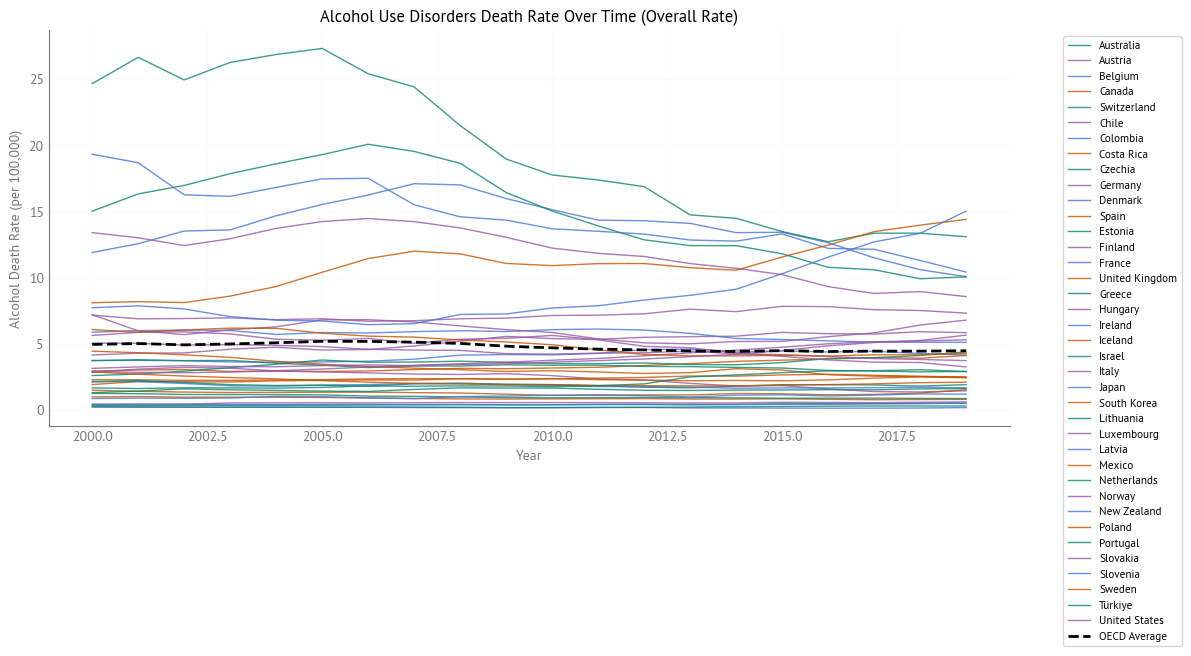

In [46]:
# Plot Alcohol rate (Mid) time series for all OECD countries
fig, ax = plot_rate_timeseries(
    alcohol_temporal.reset_index(),
    'Mid_Alcohol',
    title='Alcohol Use Disorders Death Rate Over Time (Overall Rate)',
    ylabel='Alcohol Death Rate (per 100,000)'
)
plt.savefig('jb/figs/alcohol_rate_timeseries_all.png', dpi=150, bbox_inches='tight')
plt.show()

#### Rates for Selected Countries

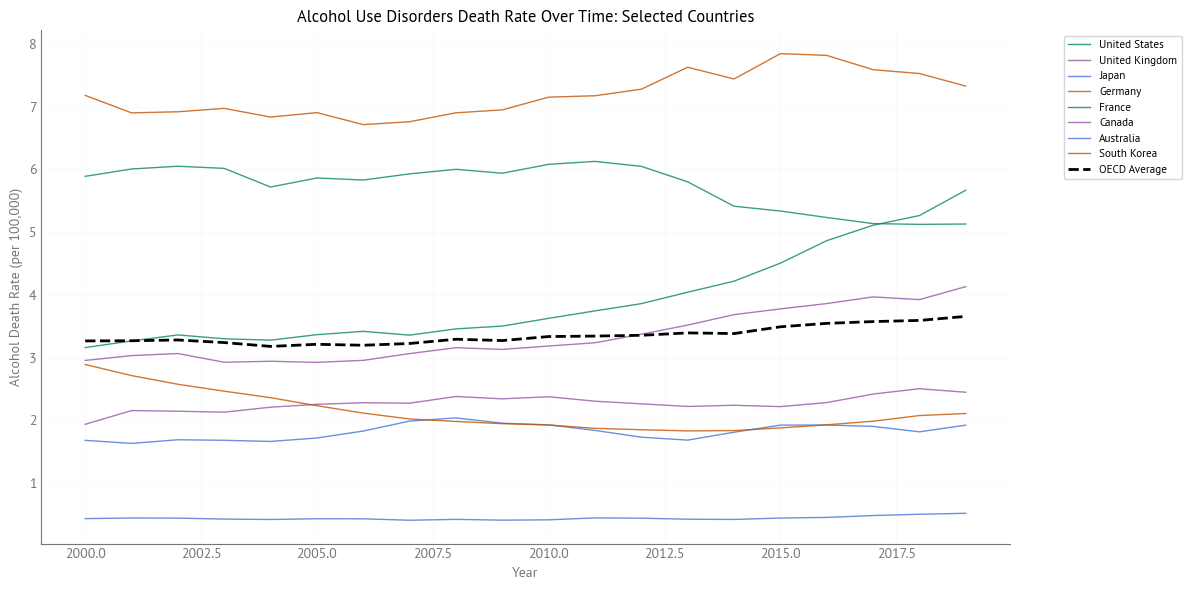

In [47]:
# Plot Alcohol rate (Mid) for selected countries
fig, ax = plot_rate_timeseries(
    alcohol_temporal.reset_index(),
    'Mid_Alcohol',
    countries=selected_countries,
    title='Alcohol Use Disorders Death Rate Over Time: Selected Countries',
    ylabel='Alcohol Death Rate (per 100,000)'
)
plt.savefig('jb/figs/alcohol_rate_timeseries_selected.png', dpi=150, bbox_inches='tight')
plt.show()

#### Gaps for All Countries

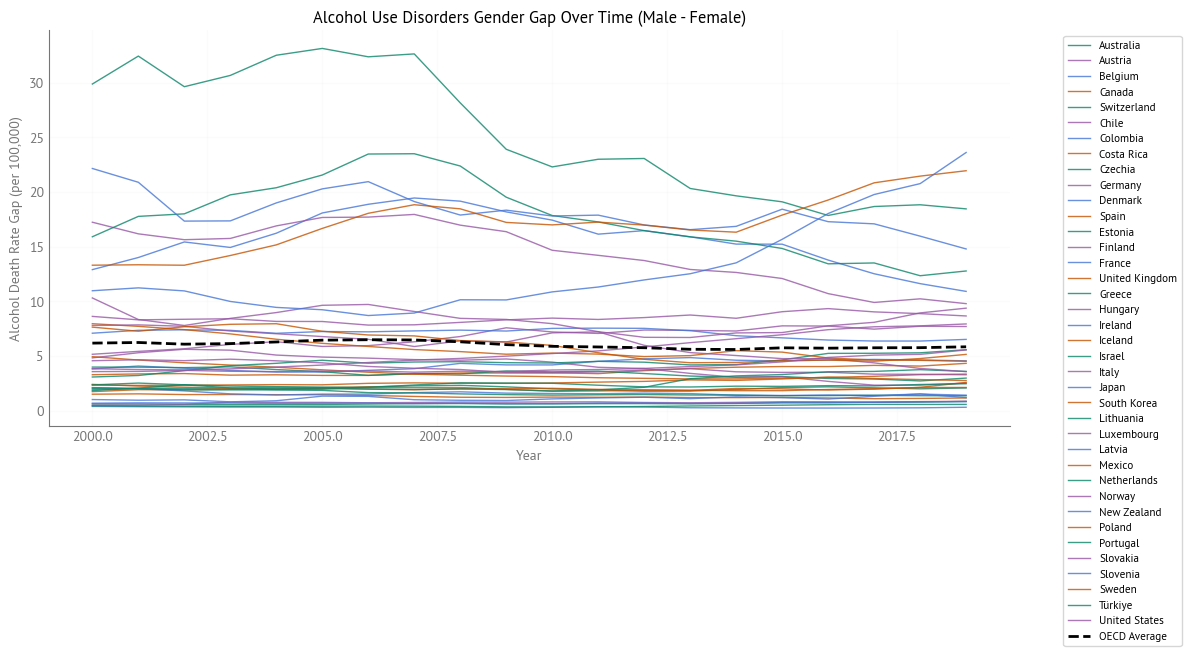

In [48]:
# Plot Alcohol gap time series for all OECD countries
fig, ax = plot_gap_timeseries(
    alcohol_temporal.reset_index(),
    'Gap_Alcohol',
    title='Alcohol Use Disorders Gender Gap Over Time (Male - Female)',
    ylabel='Alcohol Death Rate Gap (per 100,000)'
)
plt.savefig('jb/figs/alcohol_gap_timeseries_all.png', dpi=150, bbox_inches='tight')
plt.show()

#### Gaps for Selected Countries

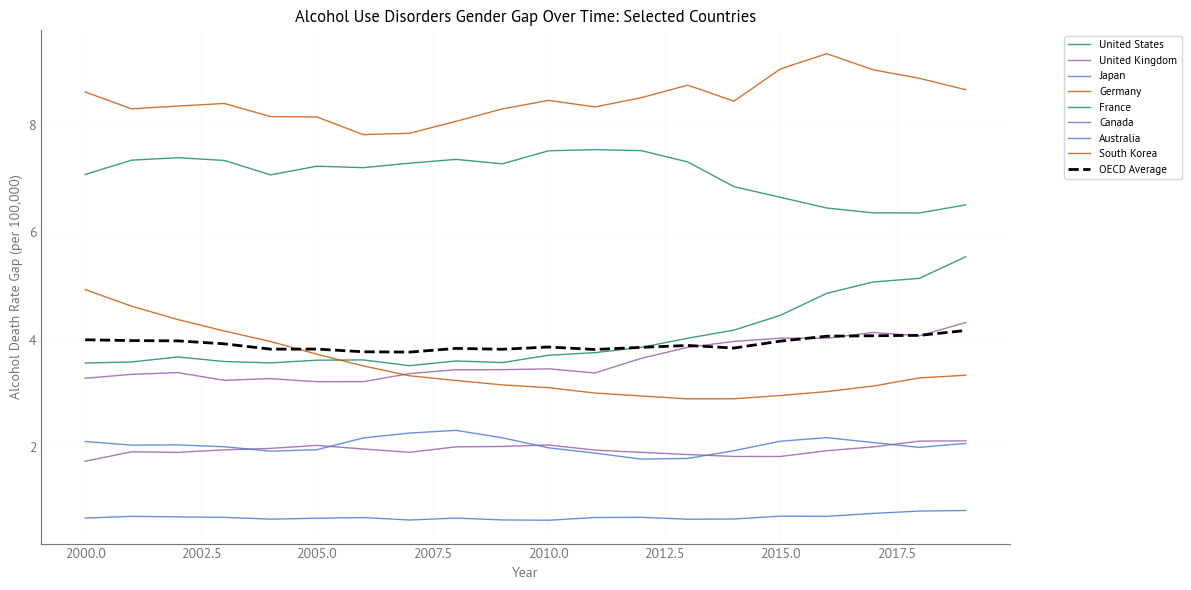

In [49]:
# Plot Alcohol gap for selected countries
fig, ax = plot_gap_timeseries(
    alcohol_temporal.reset_index(),
    'Gap_Alcohol',
    countries=selected_countries,
    title='Alcohol Use Disorders Gender Gap Over Time: Selected Countries',
    ylabel='Alcohol Death Rate Gap (per 100,000)'
)
plt.savefig('jb/figs/alcohol_gap_timeseries_selected.png', dpi=150, bbox_inches='tight')
plt.show()

### Cardiovascular Disease

#### Rates for All Countries

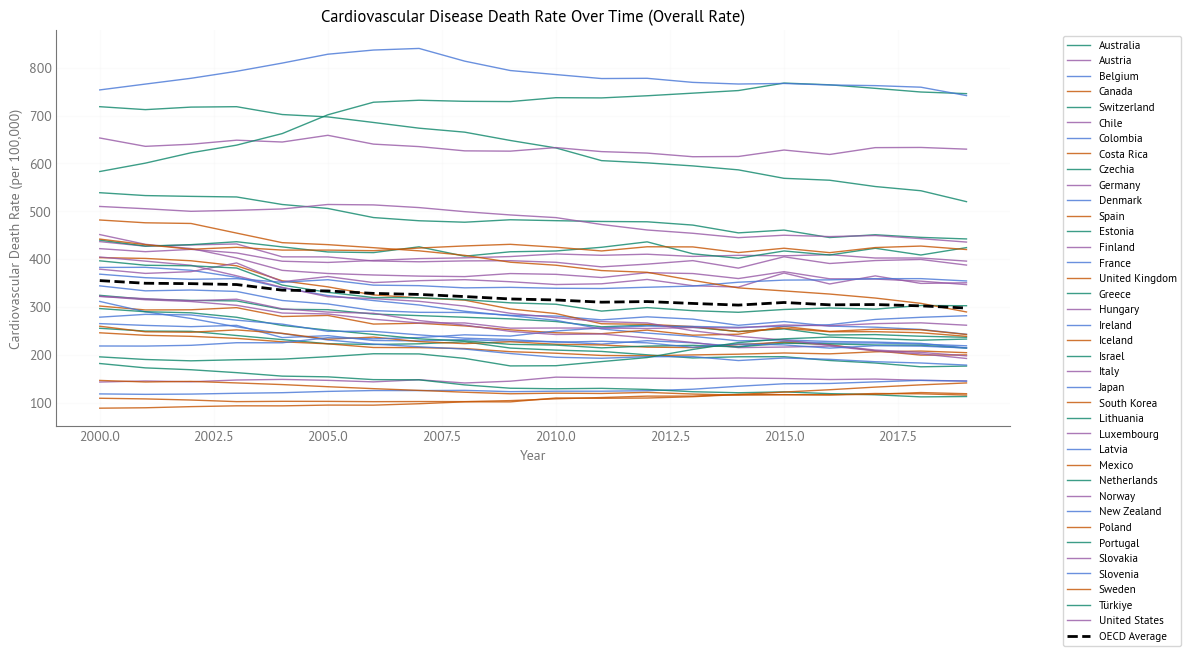

In [50]:
fig, ax = plot_rate_timeseries(
    cardiovascular_temporal.reset_index(),
    'Mid_Cardiovascular',
    title='Cardiovascular Disease Death Rate Over Time (Overall Rate)',
    ylabel='Cardiovascular Death Rate (per 100,000)'
)
plt.savefig('jb/figs/cardiovascular_rate_timeseries_all.png', dpi=150, bbox_inches='tight')
plt.show()

#### Rates for Selected Countries

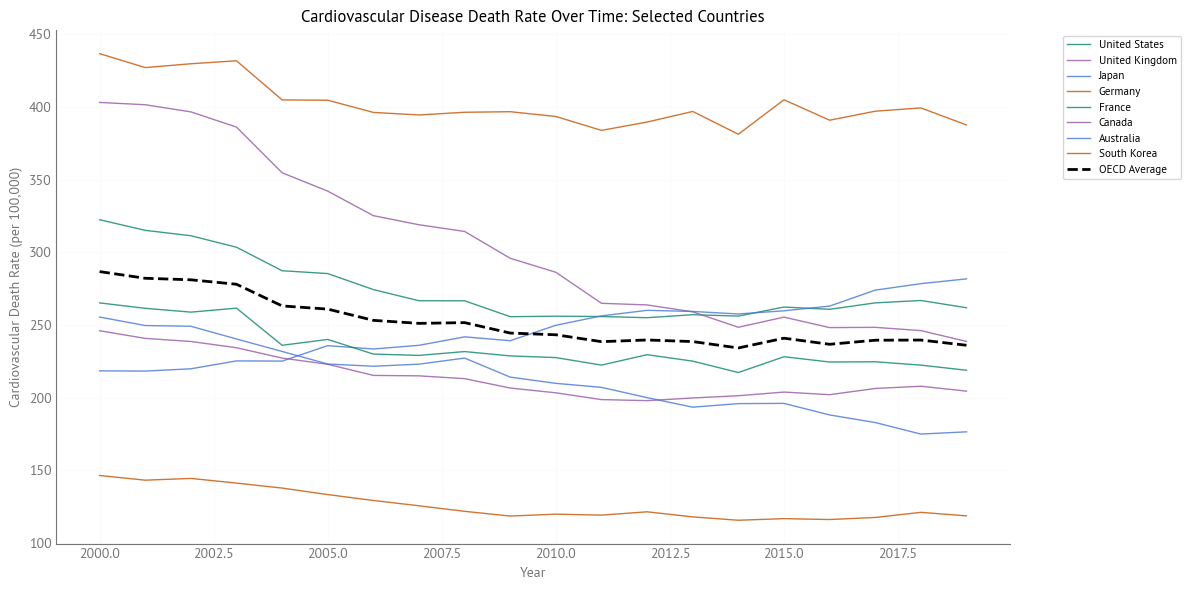

In [51]:
fig, ax = plot_rate_timeseries(
    cardiovascular_temporal.reset_index(),
    'Mid_Cardiovascular',
    countries=selected_countries,
    title='Cardiovascular Disease Death Rate Over Time: Selected Countries',
    ylabel='Cardiovascular Death Rate (per 100,000)'
)
plt.savefig('jb/figs/cardiovascular_rate_timeseries_selected.png', dpi=150, bbox_inches='tight')
plt.show()

#### Gaps for All Countries

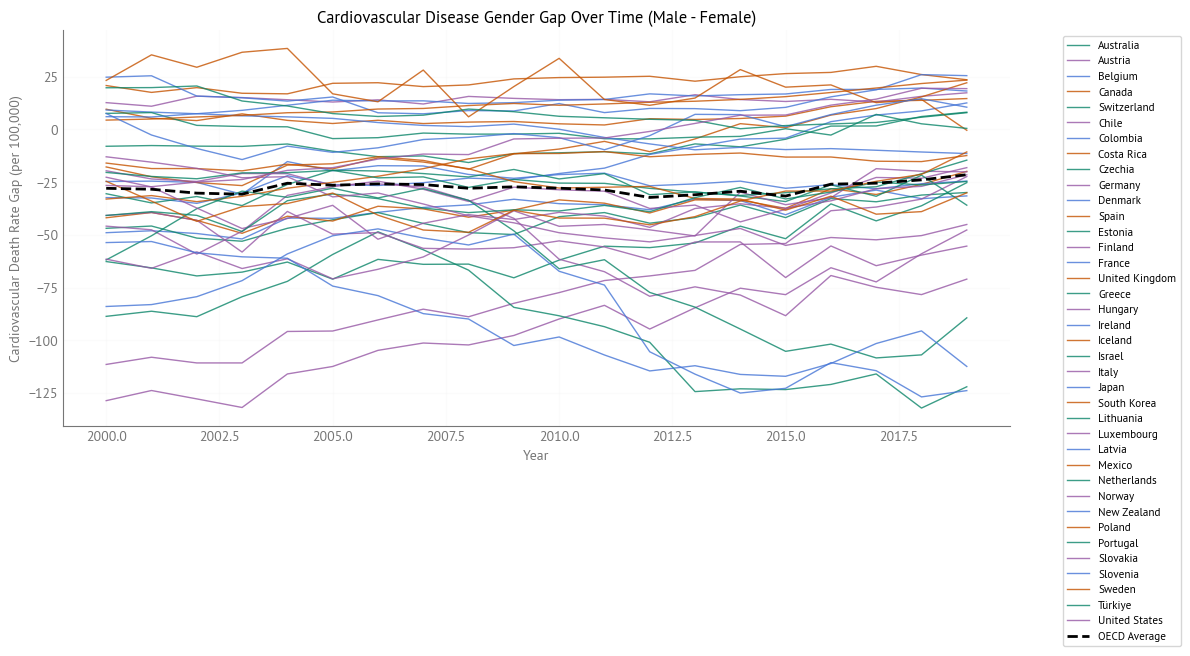

In [52]:
fig, ax = plot_gap_timeseries(
    cardiovascular_temporal.reset_index(),
    'Gap_Cardiovascular',
    title='Cardiovascular Disease Gender Gap Over Time (Male - Female)',
    ylabel='Cardiovascular Death Rate Gap (per 100,000)'
)
plt.savefig('jb/figs/cardiovascular_gap_timeseries_all.png', dpi=150, bbox_inches='tight')
plt.show()

#### Gaps for Selected Countries

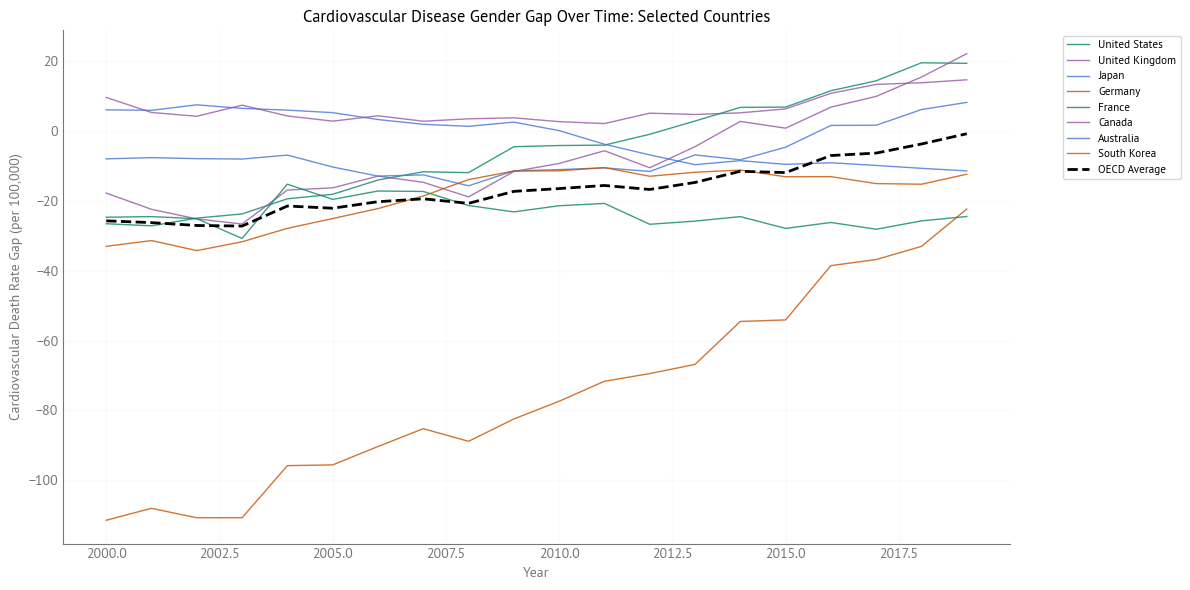

In [53]:
fig, ax = plot_gap_timeseries(
    cardiovascular_temporal.reset_index(),
    'Gap_Cardiovascular',
    countries=selected_countries,
    title='Cardiovascular Disease Gender Gap Over Time: Selected Countries',
    ylabel='Cardiovascular Death Rate Gap (per 100,000)'
)
plt.savefig('jb/figs/cardiovascular_gap_timeseries_selected.png', dpi=150, bbox_inches='tight')
plt.show()

### Chronic Respiratory Disease

#### Rates for All Countries

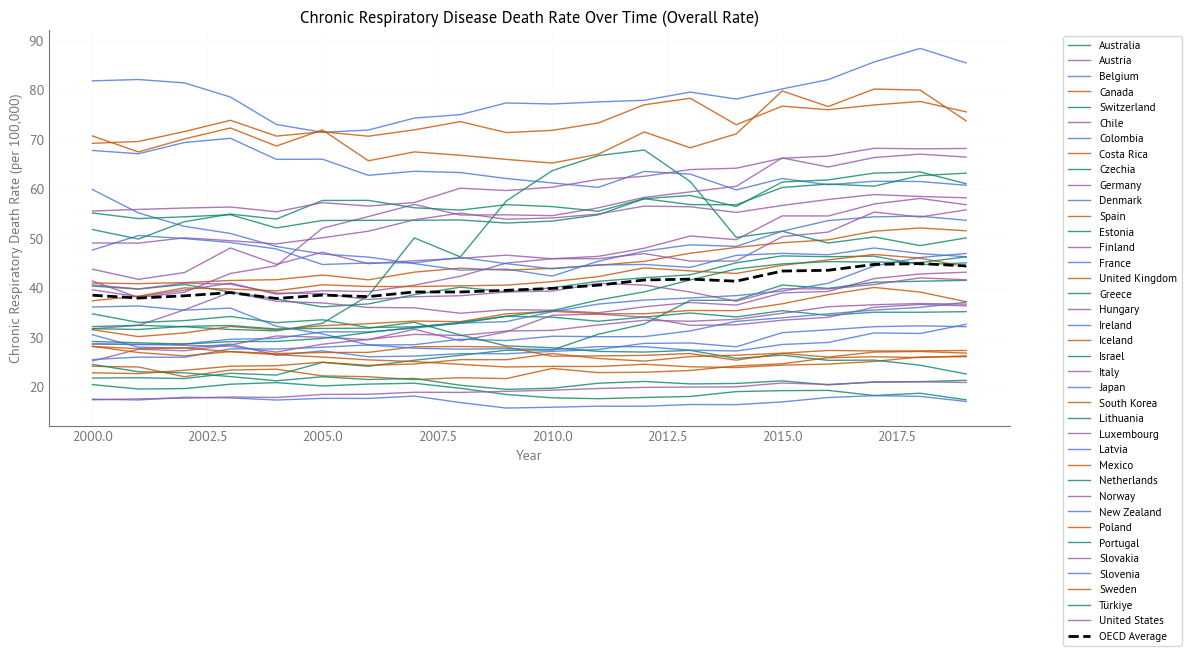

In [54]:
fig, ax = plot_rate_timeseries(
    chronic_respiratory_temporal.reset_index(),
    'Mid_ChronicRespiratory',
    title='Chronic Respiratory Disease Death Rate Over Time (Overall Rate)',
    ylabel='Chronic Respiratory Death Rate (per 100,000)'
)
plt.savefig('jb/figs/chronic_respiratory_rate_timeseries_all.png', dpi=150, bbox_inches='tight')
plt.show()

#### Rates for Selected Countries

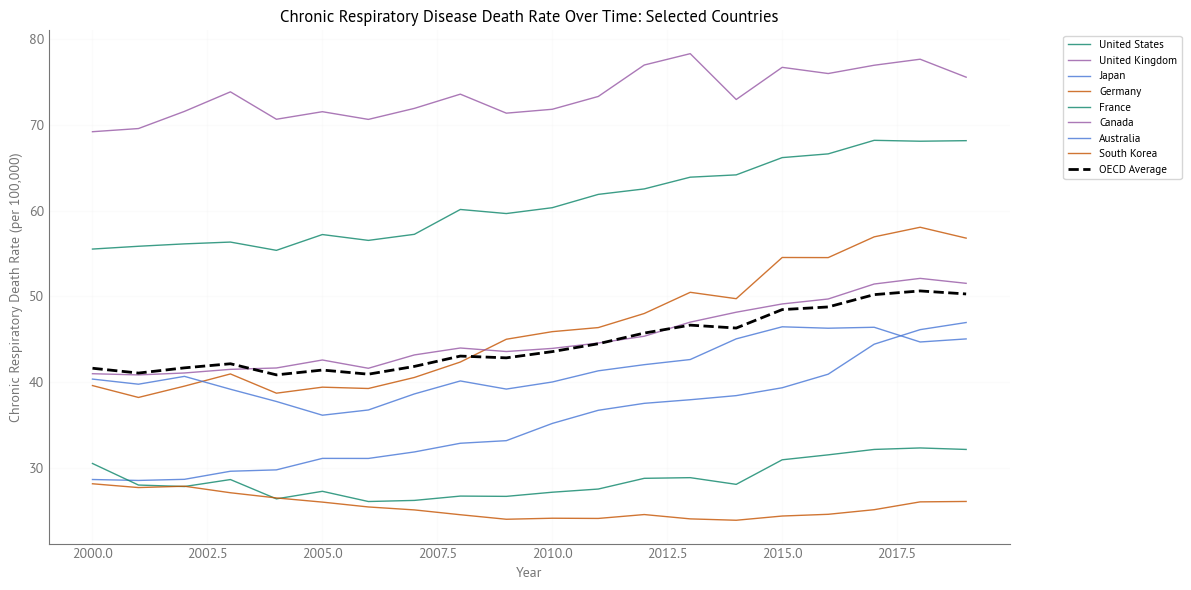

In [55]:
fig, ax = plot_rate_timeseries(
    chronic_respiratory_temporal.reset_index(),
    'Mid_ChronicRespiratory',
    countries=selected_countries,
    title='Chronic Respiratory Disease Death Rate Over Time: Selected Countries',
    ylabel='Chronic Respiratory Death Rate (per 100,000)'
)
plt.savefig('jb/figs/chronic_respiratory_rate_timeseries_selected.png', dpi=150, bbox_inches='tight')
plt.show()

#### Gaps for All Countries

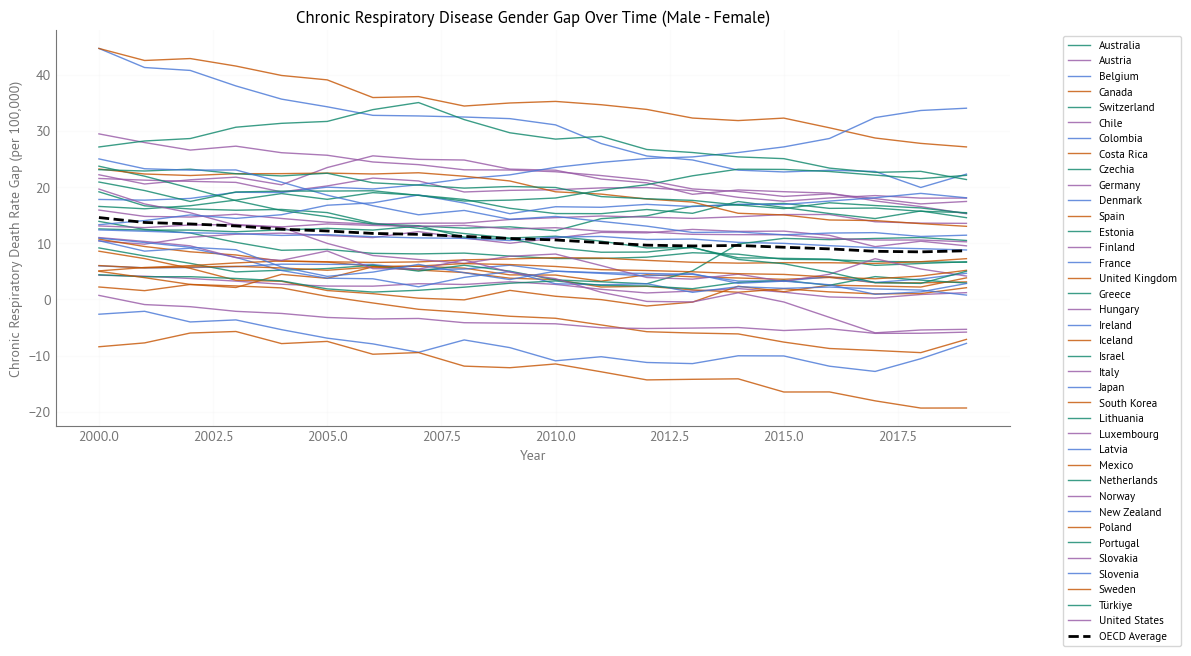

In [56]:
fig, ax = plot_gap_timeseries(
    chronic_respiratory_temporal.reset_index(),
    'Gap_ChronicRespiratory',
    title='Chronic Respiratory Disease Gender Gap Over Time (Male - Female)',
    ylabel='Chronic Respiratory Death Rate Gap (per 100,000)'
)
plt.savefig('jb/figs/chronic_respiratory_gap_timeseries_all.png', dpi=150, bbox_inches='tight')
plt.show()

#### Gaps for Selected Countries

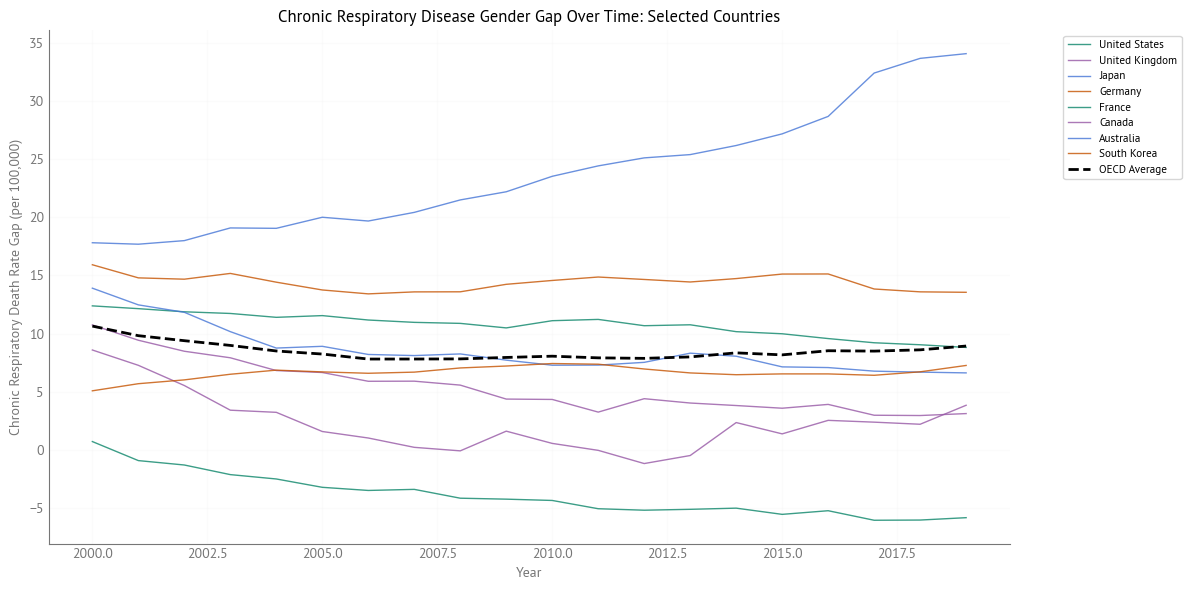

In [57]:
fig, ax = plot_gap_timeseries(
    chronic_respiratory_temporal.reset_index(),
    'Gap_ChronicRespiratory',
    countries=selected_countries,
    title='Chronic Respiratory Disease Gender Gap Over Time: Selected Countries',
    ylabel='Chronic Respiratory Death Rate Gap (per 100,000)'
)
plt.savefig('jb/figs/chronic_respiratory_gap_timeseries_selected.png', dpi=150, bbox_inches='tight')
plt.show()

### Self-Harm/Suicide

#### Rates for All Countries

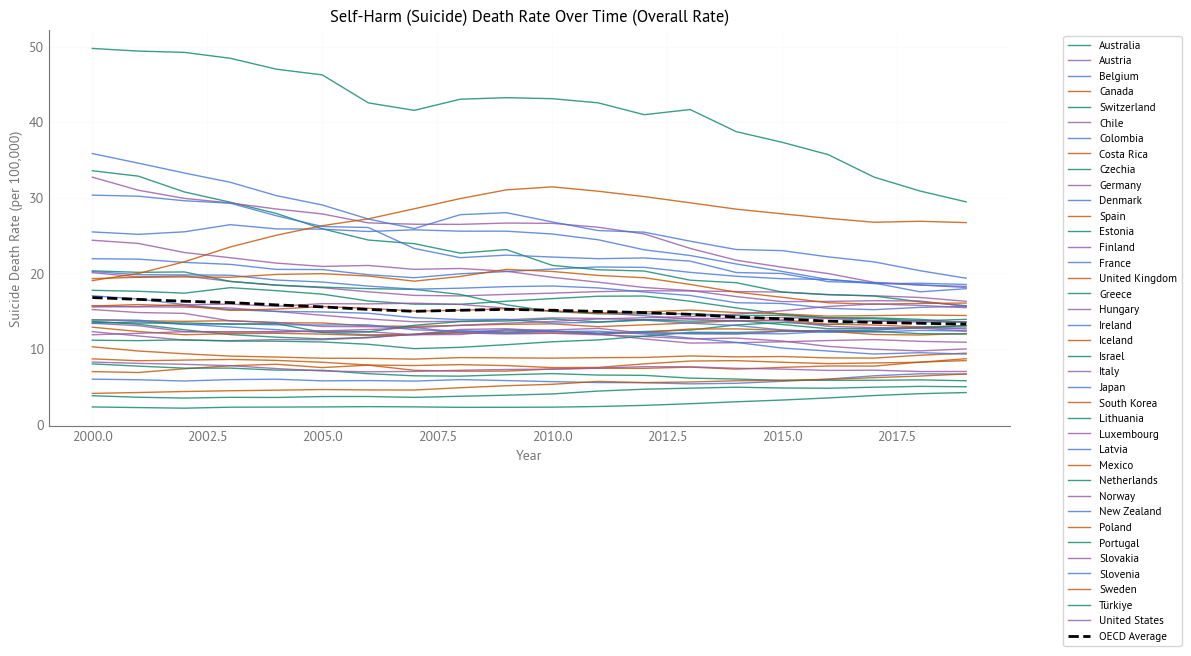

In [58]:
fig, ax = plot_rate_timeseries(
    self_harm_temporal.reset_index(),
    'Mid_Suicide',
    title='Self-Harm (Suicide) Death Rate Over Time (Overall Rate)',
    ylabel='Suicide Death Rate (per 100,000)'
)
plt.savefig('jb/figs/suicide_rate_timeseries_all.png', dpi=150, bbox_inches='tight')
plt.show()

#### Rates for Selected Countries

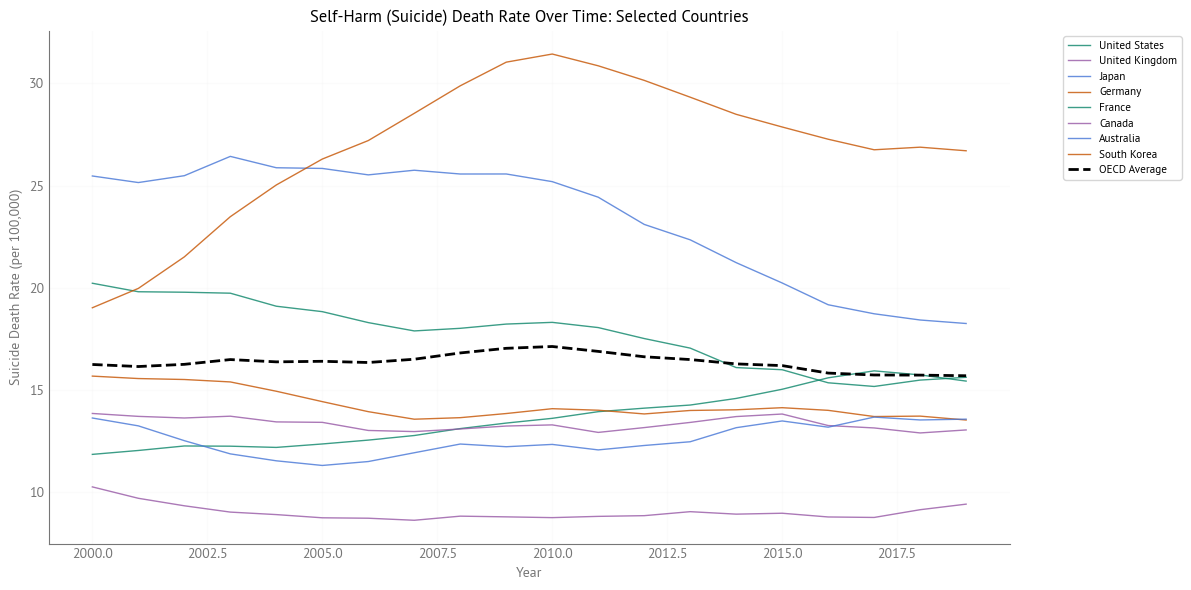

In [59]:
fig, ax = plot_rate_timeseries(
    self_harm_temporal.reset_index(),
    'Mid_Suicide',
    countries=selected_countries,
    title='Self-Harm (Suicide) Death Rate Over Time: Selected Countries',
    ylabel='Suicide Death Rate (per 100,000)'
)
plt.savefig('jb/figs/suicide_rate_timeseries_selected.png', dpi=150, bbox_inches='tight')
plt.show()

#### Gaps for All Countries

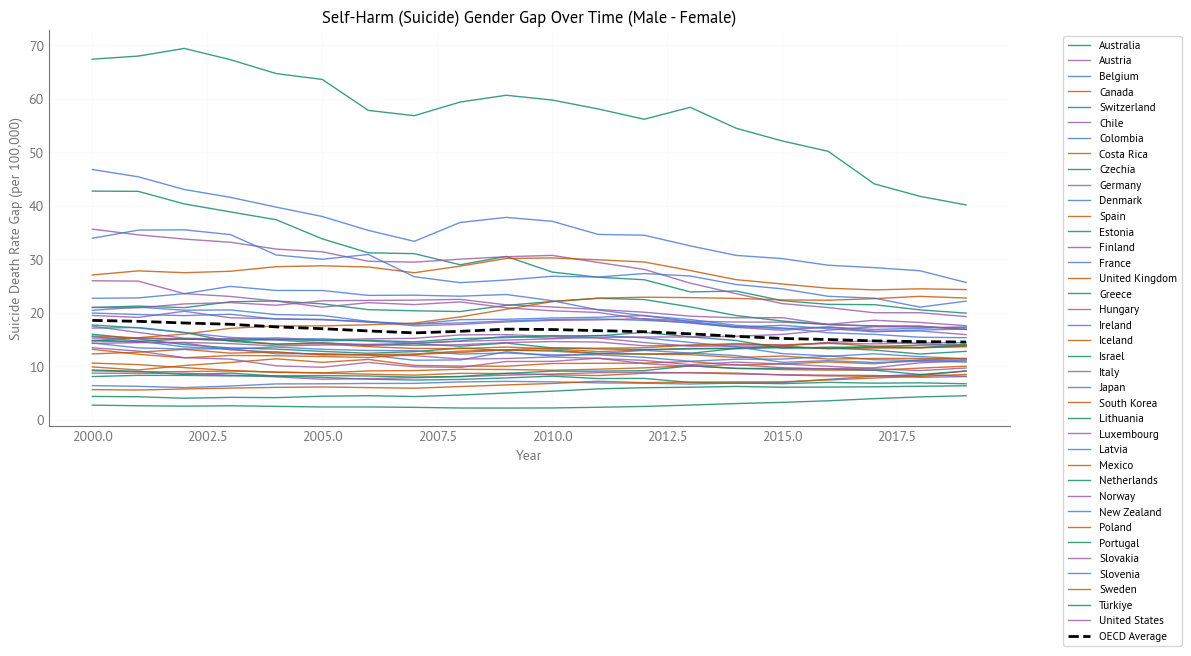

In [60]:
fig, ax = plot_gap_timeseries(
    self_harm_temporal.reset_index(),
    'Gap_Suicide',
    title='Self-Harm (Suicide) Gender Gap Over Time (Male - Female)',
    ylabel='Suicide Death Rate Gap (per 100,000)'
)
plt.savefig('jb/figs/suicide_gap_timeseries_all.png', dpi=150, bbox_inches='tight')
plt.show()

#### Gaps for Selected Countries

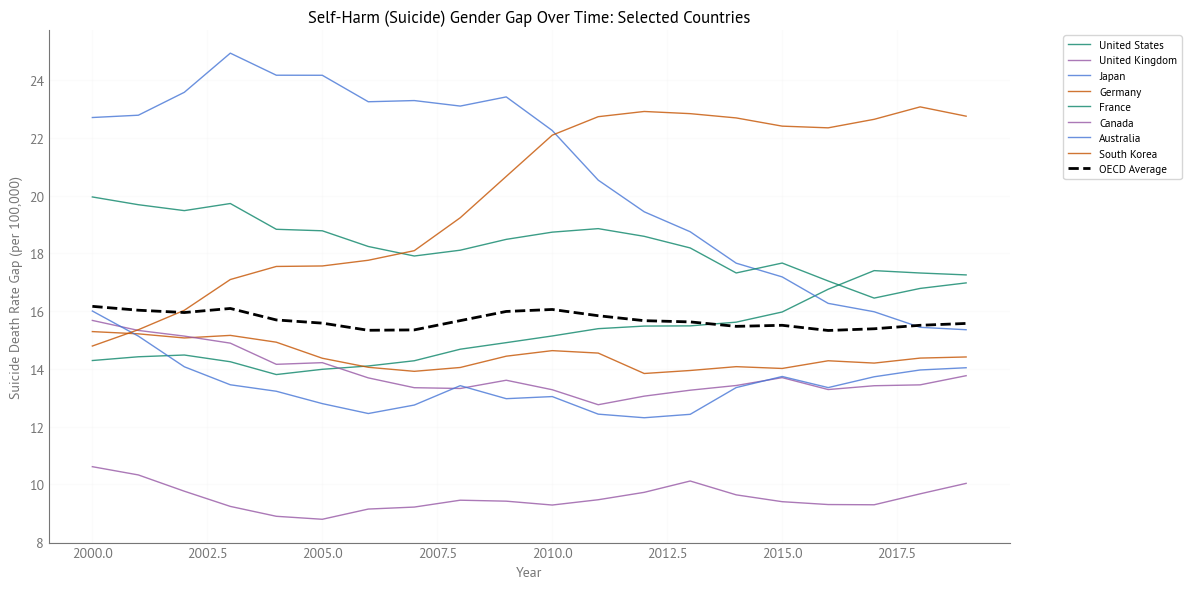

In [61]:
fig, ax = plot_gap_timeseries(
    self_harm_temporal.reset_index(),
    'Gap_Suicide',
    countries=selected_countries,
    title='Self-Harm (Suicide) Gender Gap Over Time: Selected Countries',
    ylabel='Suicide Death Rate Gap (per 100,000)'
)
plt.savefig('jb/figs/suicide_gap_timeseries_selected.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpersonal Violence/Homicide

#### Rates for All Countries

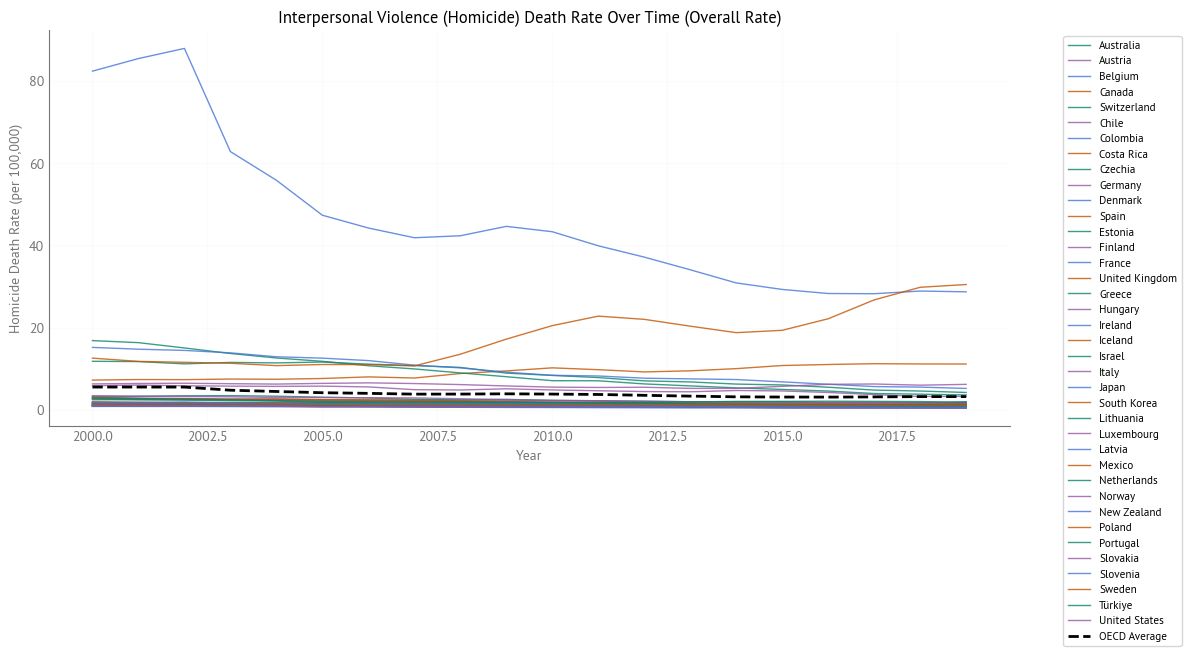

In [62]:
fig, ax = plot_rate_timeseries(
    interpersonal_violence_temporal.reset_index(),
    'Mid_Homicide',
    title='Interpersonal Violence (Homicide) Death Rate Over Time (Overall Rate)',
    ylabel='Homicide Death Rate (per 100,000)'
)
plt.savefig('jb/figs/homicide_rate_timeseries_all.png', dpi=150, bbox_inches='tight')
plt.show()

#### Rates for Selected Countries

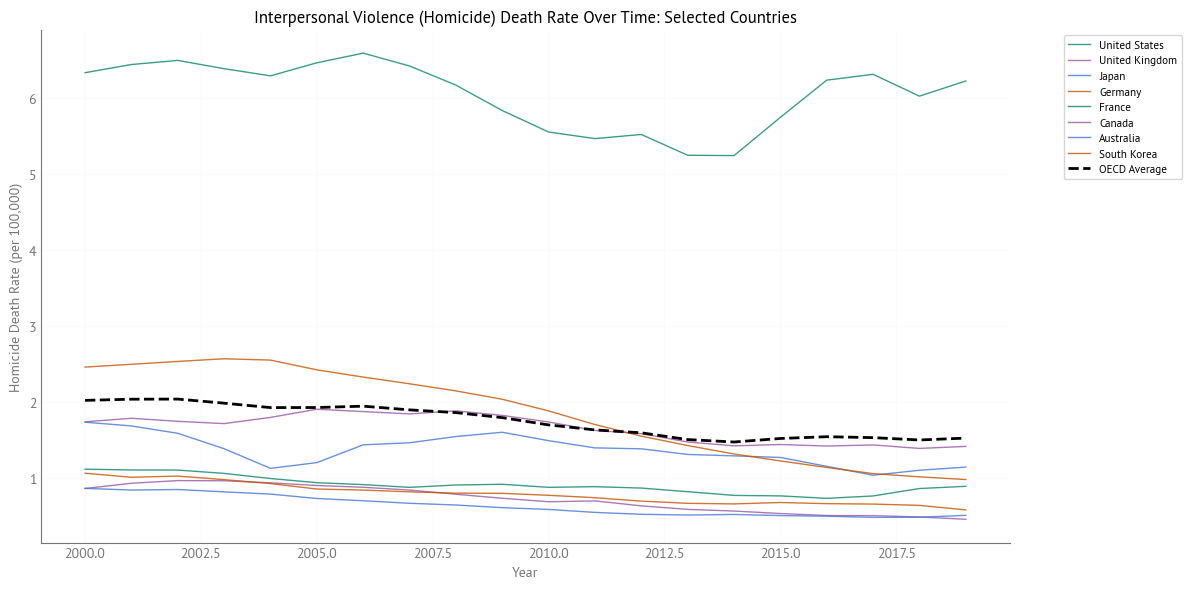

In [63]:
fig, ax = plot_rate_timeseries(
    interpersonal_violence_temporal.reset_index(),
    'Mid_Homicide',
    countries=selected_countries,
    title='Interpersonal Violence (Homicide) Death Rate Over Time: Selected Countries',
    ylabel='Homicide Death Rate (per 100,000)'
)
plt.savefig('jb/figs/homicide_rate_timeseries_selected.png', dpi=150, bbox_inches='tight')
plt.show()

#### Gaps for All Countries

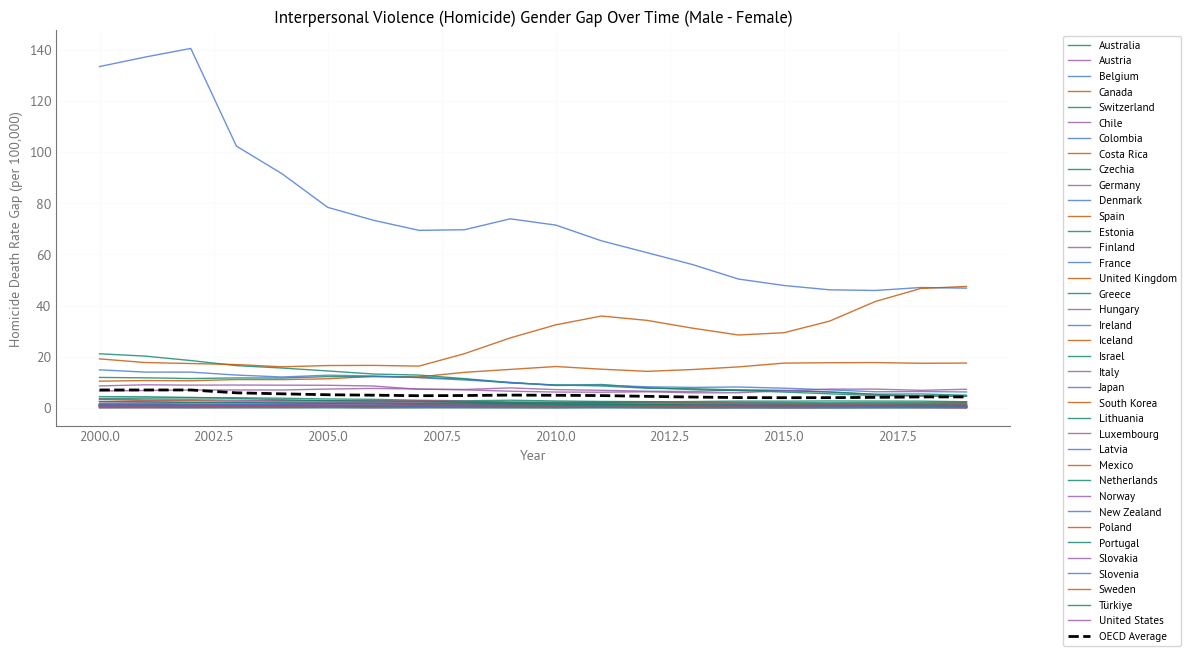

In [64]:
fig, ax = plot_gap_timeseries(
    interpersonal_violence_temporal.reset_index(),
    'Gap_Homicide',
    title='Interpersonal Violence (Homicide) Gender Gap Over Time (Male - Female)',
    ylabel='Homicide Death Rate Gap (per 100,000)'
)
plt.savefig('jb/figs/homicide_gap_timeseries_all.png', dpi=150, bbox_inches='tight')
plt.show()

#### Gaps for Selected Countries

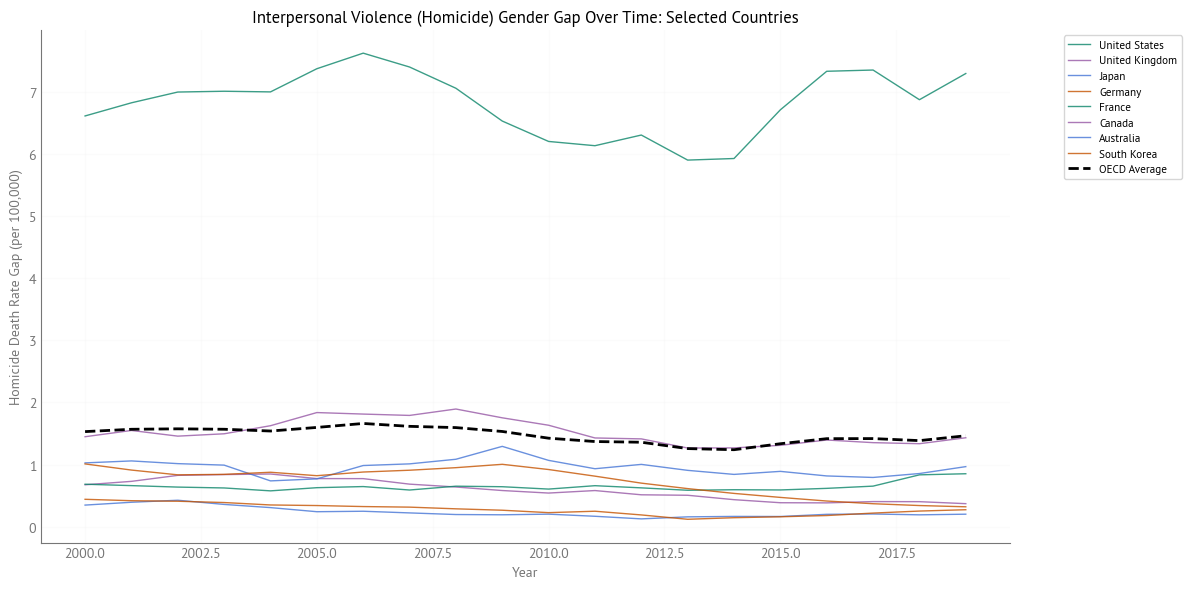

In [65]:
fig, ax = plot_gap_timeseries(
    interpersonal_violence_temporal.reset_index(),
    'Gap_Homicide',
    countries=selected_countries,
    title='Interpersonal Violence (Homicide) Gender Gap Over Time: Selected Countries',
    ylabel='Homicide Death Rate Gap (per 100,000)'
)
plt.savefig('jb/figs/homicide_gap_timeseries_selected.png', dpi=150, bbox_inches='tight')
plt.show()

### Road Injuries

#### Rates for All Countries

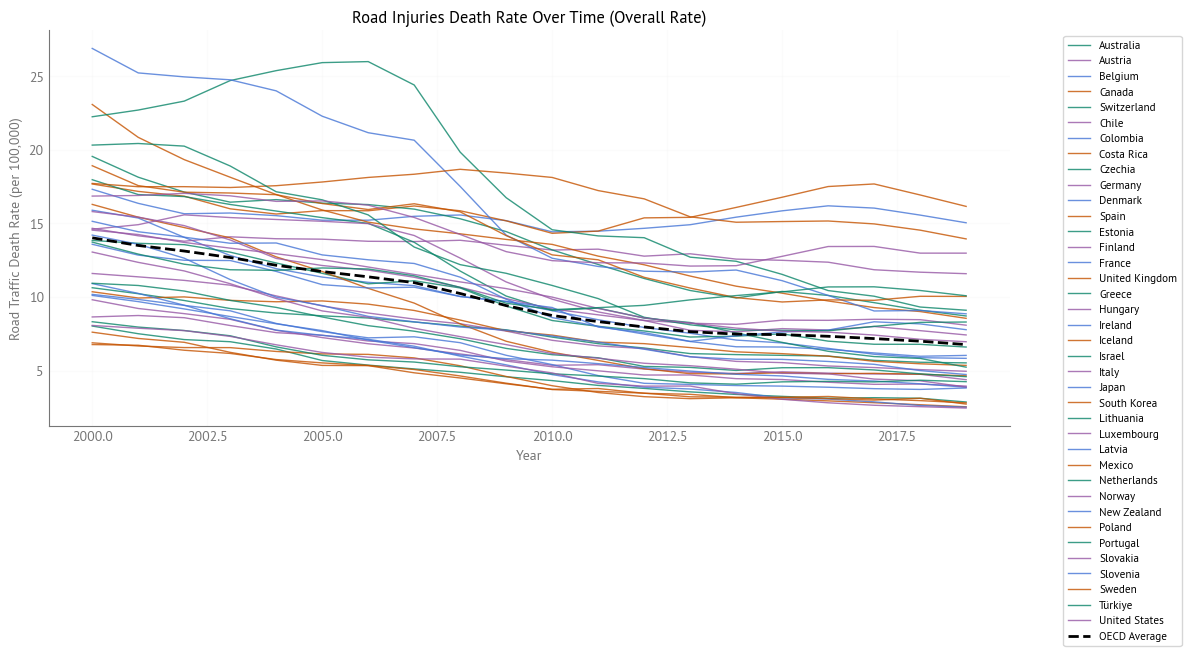

In [66]:
fig, ax = plot_rate_timeseries(
    road_injuries_temporal.reset_index(),
    'Mid_RoadTraffic',
    title='Road Injuries Death Rate Over Time (Overall Rate)',
    ylabel='Road Traffic Death Rate (per 100,000)'
)
plt.savefig('jb/figs/road_traffic_rate_timeseries_all.png', dpi=150, bbox_inches='tight')
plt.show()

#### Rates for Selected Countries

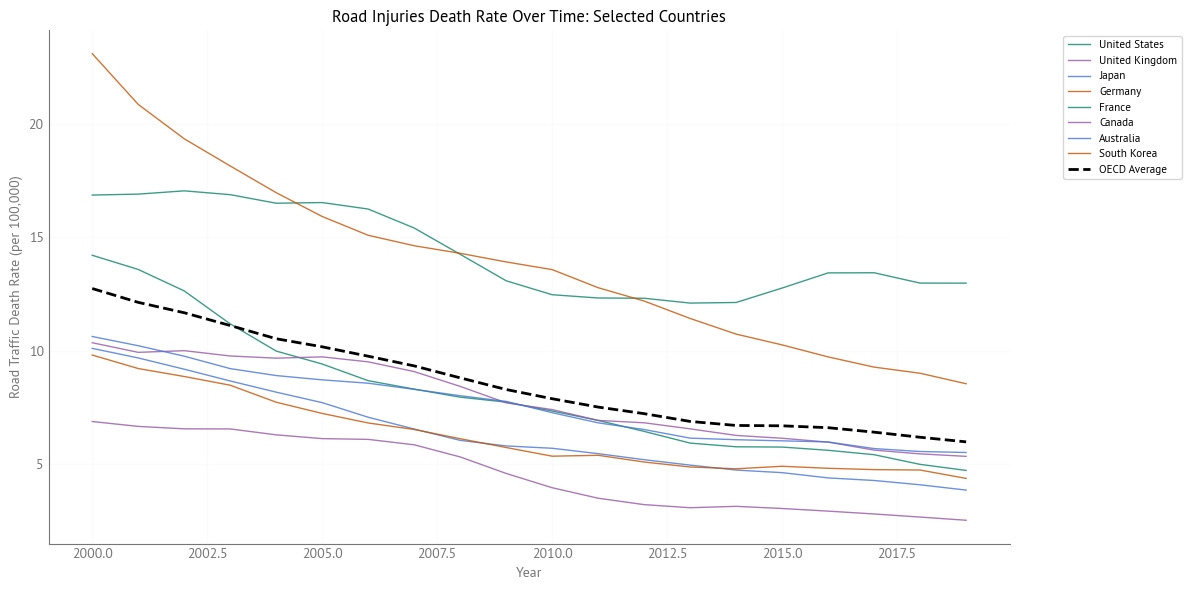

In [67]:
fig, ax = plot_rate_timeseries(
    road_injuries_temporal.reset_index(),
    'Mid_RoadTraffic',
    countries=selected_countries,
    title='Road Injuries Death Rate Over Time: Selected Countries',
    ylabel='Road Traffic Death Rate (per 100,000)'
)
plt.savefig('jb/figs/road_traffic_rate_timeseries_selected.png', dpi=150, bbox_inches='tight')
plt.show()

#### Gaps for All Countries

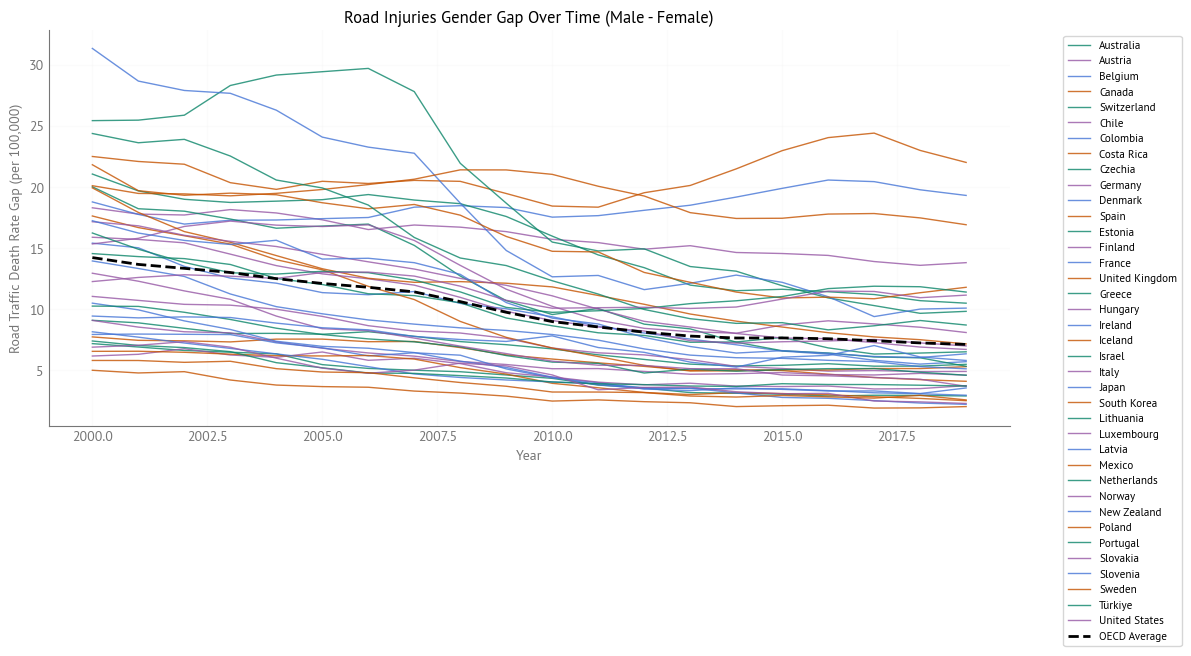

In [68]:
fig, ax = plot_gap_timeseries(
    road_injuries_temporal.reset_index(),
    'Gap_RoadTraffic',
    title='Road Injuries Gender Gap Over Time (Male - Female)',
    ylabel='Road Traffic Death Rate Gap (per 100,000)'
)
plt.savefig('jb/figs/road_traffic_gap_timeseries_all.png', dpi=150, bbox_inches='tight')
plt.show()

#### Gaps for Selected Countries

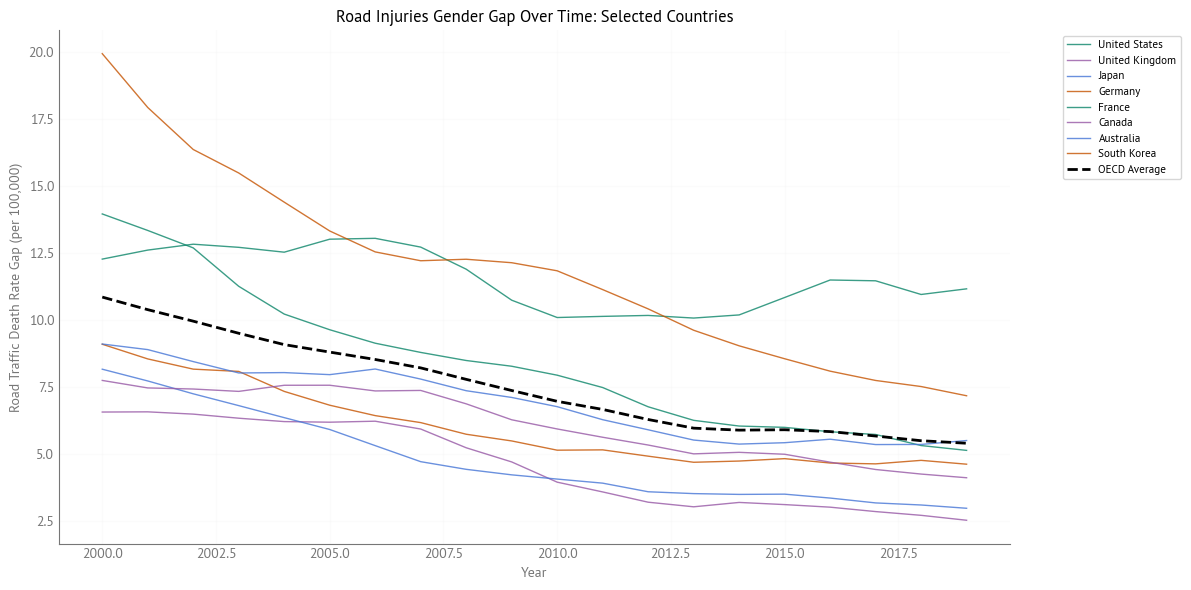

In [69]:
fig, ax = plot_gap_timeseries(
    road_injuries_temporal.reset_index(),
    'Gap_RoadTraffic',
    countries=selected_countries,
    title='Road Injuries Gender Gap Over Time: Selected Countries',
    ylabel='Road Traffic Death Rate Gap (per 100,000)'
)
plt.savefig('jb/figs/road_traffic_gap_timeseries_selected.png', dpi=150, bbox_inches='tight')
plt.show()

### Liver Disease

#### Rates for All Countries

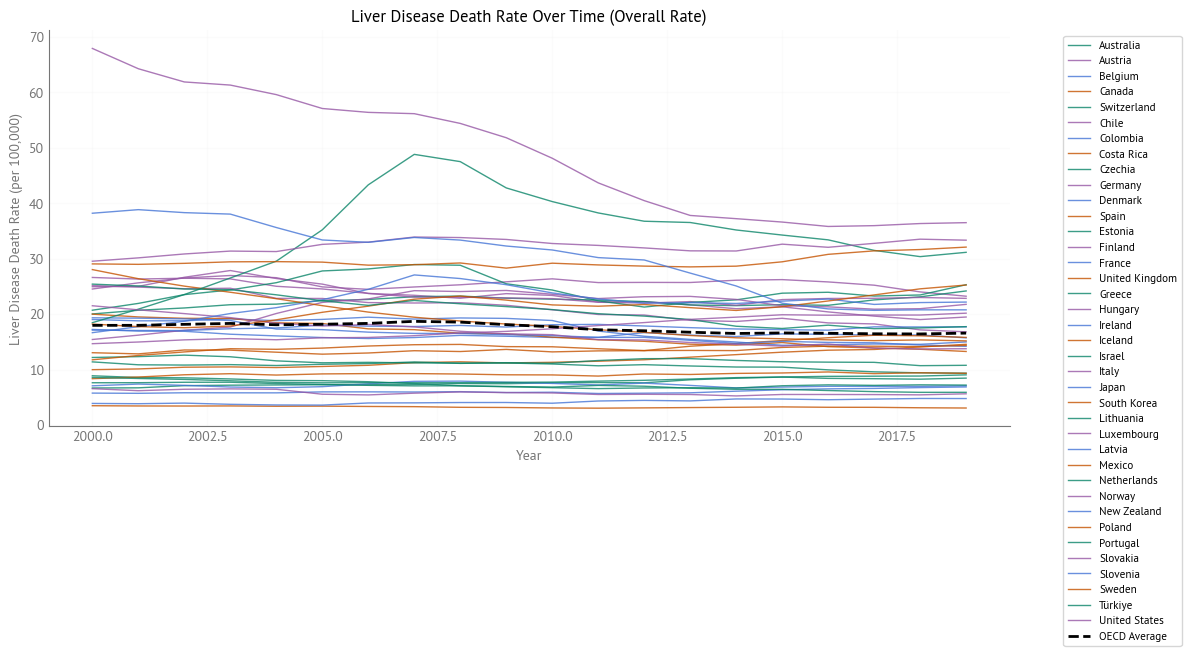

In [70]:
fig, ax = plot_rate_timeseries(
    liver_disease_temporal.reset_index(),
    'Mid_LiverDisease',
    title='Liver Disease Death Rate Over Time (Overall Rate)',
    ylabel='Liver Disease Death Rate (per 100,000)'
)
plt.savefig('jb/figs/liver_disease_rate_timeseries_all.png', dpi=150, bbox_inches='tight')
plt.show()

#### Rates for Selected Countries

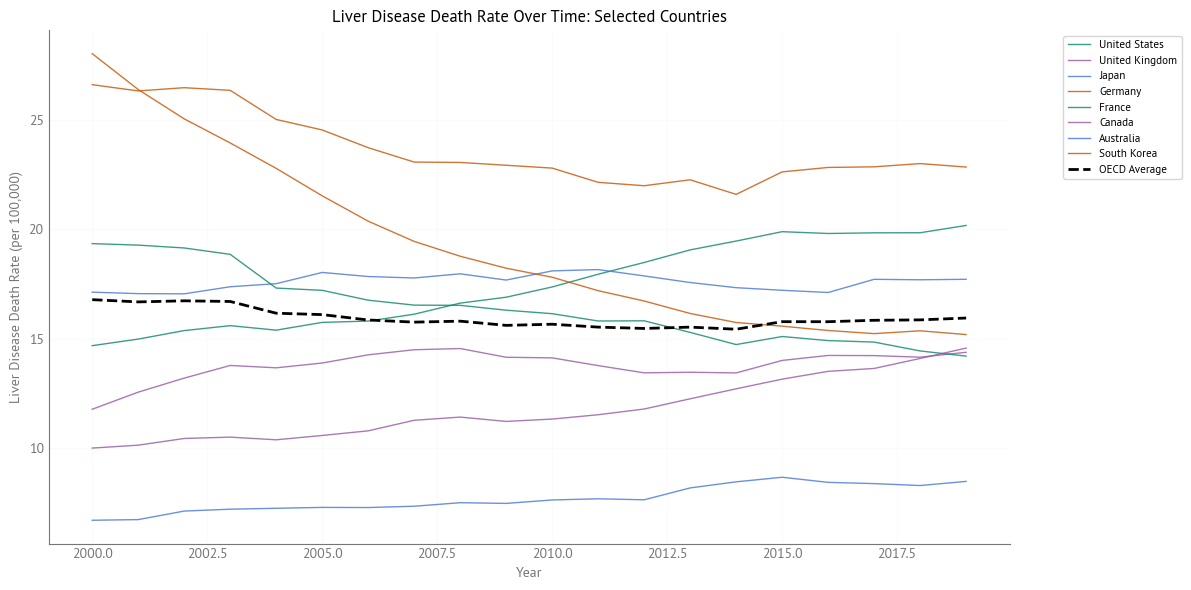

In [71]:
fig, ax = plot_rate_timeseries(
    liver_disease_temporal.reset_index(),
    'Mid_LiverDisease',
    countries=selected_countries,
    title='Liver Disease Death Rate Over Time: Selected Countries',
    ylabel='Liver Disease Death Rate (per 100,000)'
)
plt.savefig('jb/figs/liver_disease_rate_timeseries_selected.png', dpi=150, bbox_inches='tight')
plt.show()

#### Gaps for All Countries

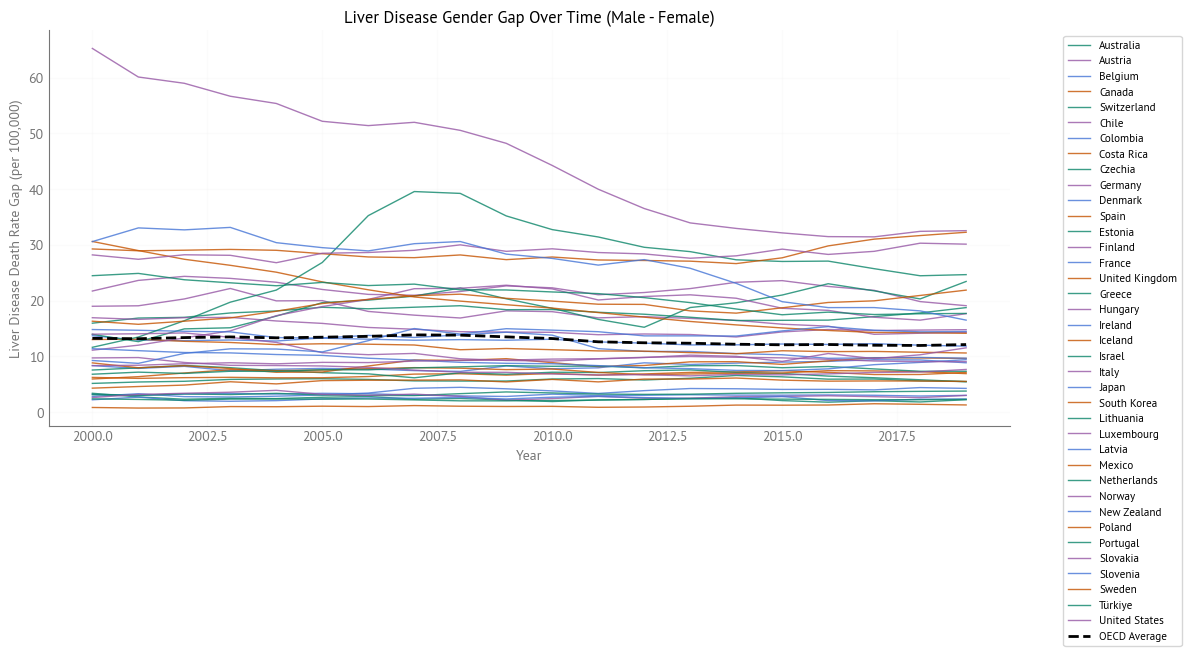

In [72]:
fig, ax = plot_gap_timeseries(
    liver_disease_temporal.reset_index(),
    'Gap_LiverDisease',
    title='Liver Disease Gender Gap Over Time (Male - Female)',
    ylabel='Liver Disease Death Rate Gap (per 100,000)'
)
plt.savefig('jb/figs/liver_disease_gap_timeseries_all.png', dpi=150, bbox_inches='tight')
plt.show()

#### Gaps for Selected Countries

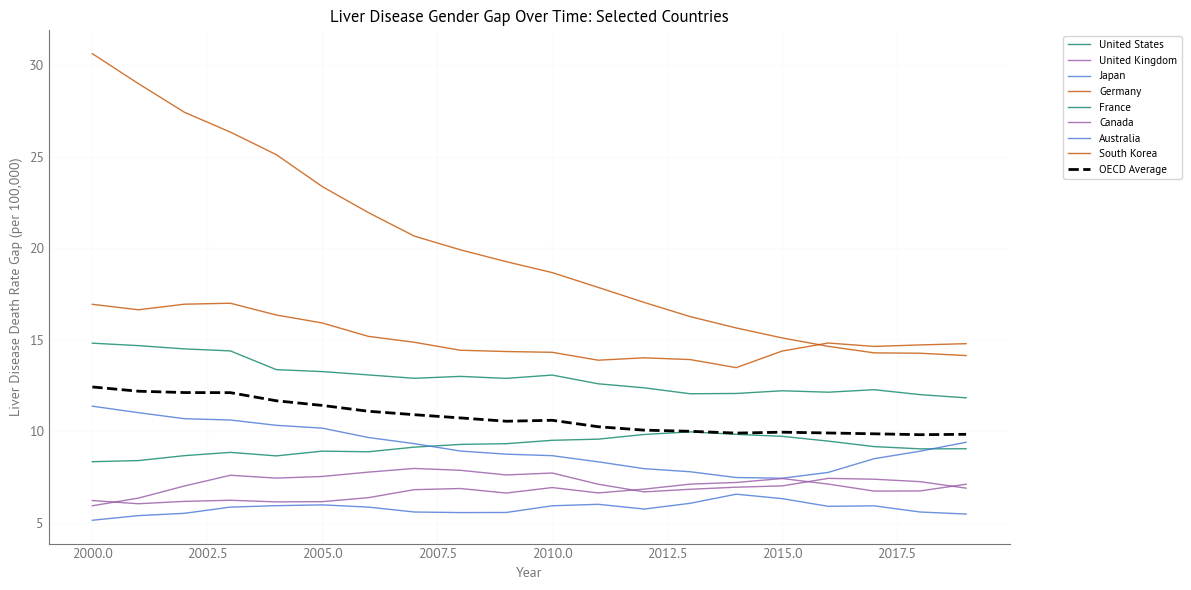

In [73]:
fig, ax = plot_gap_timeseries(
    liver_disease_temporal.reset_index(),
    'Gap_LiverDisease',
    countries=selected_countries,
    title='Liver Disease Gender Gap Over Time: Selected Countries',
    ylabel='Liver Disease Death Rate Gap (per 100,000)'
)
plt.savefig('jb/figs/liver_disease_gap_timeseries_selected.png', dpi=150, bbox_inches='tight')
plt.show()

### Neoplasms

#### Rates for All Countries

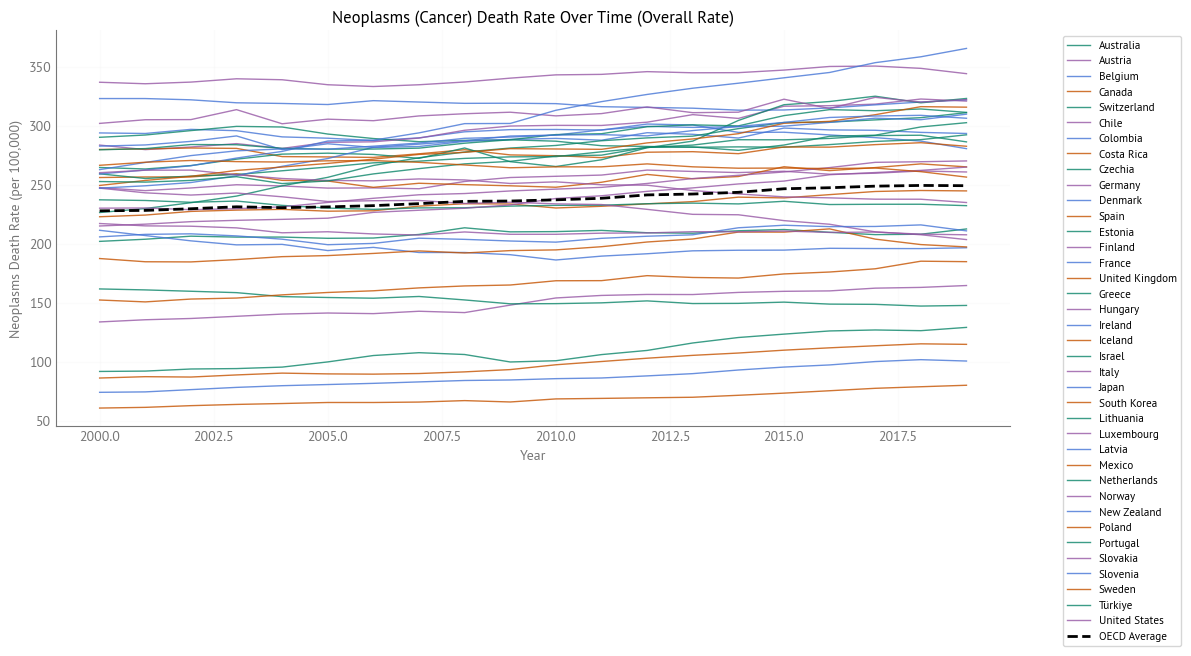

In [74]:
fig, ax = plot_rate_timeseries(
    neoplasms_temporal.reset_index(),
    'Mid_Neoplasms',
    title='Neoplasms (Cancer) Death Rate Over Time (Overall Rate)',
    ylabel='Neoplasms Death Rate (per 100,000)'
)
plt.savefig('jb/figs/neoplasms_rate_timeseries_all.png', dpi=150, bbox_inches='tight')
plt.show()

#### Rates for Selected Countries

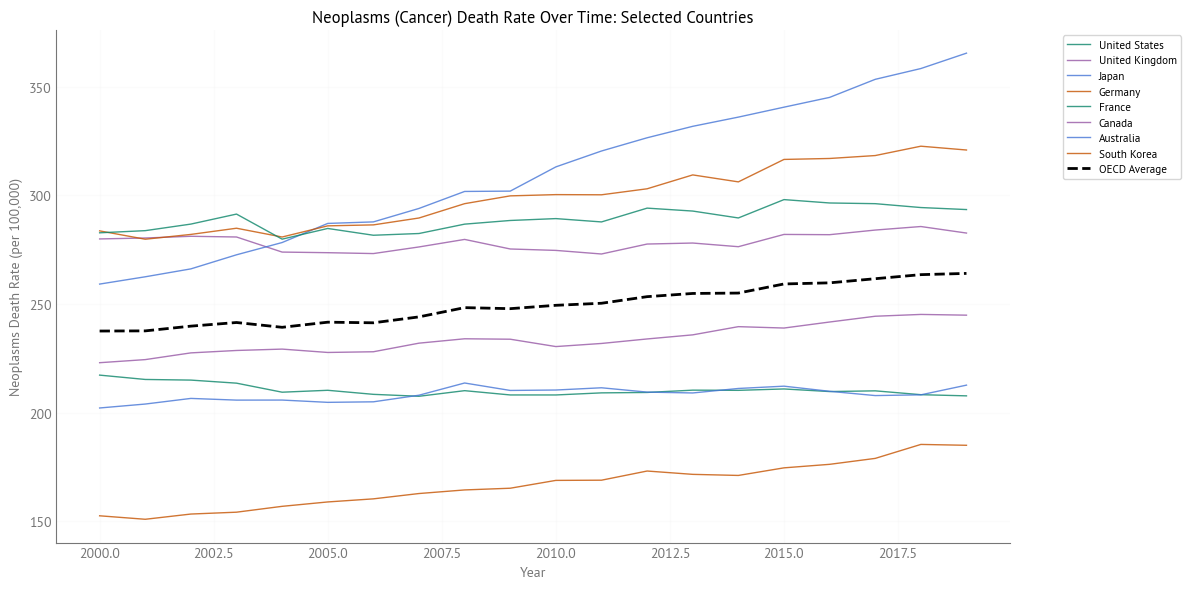

In [75]:
fig, ax = plot_rate_timeseries(
    neoplasms_temporal.reset_index(),
    'Mid_Neoplasms',
    countries=selected_countries,
    title='Neoplasms (Cancer) Death Rate Over Time: Selected Countries',
    ylabel='Neoplasms Death Rate (per 100,000)'
)
plt.savefig('jb/figs/neoplasms_rate_timeseries_selected.png', dpi=150, bbox_inches='tight')
plt.show()

#### Gaps for All Countries

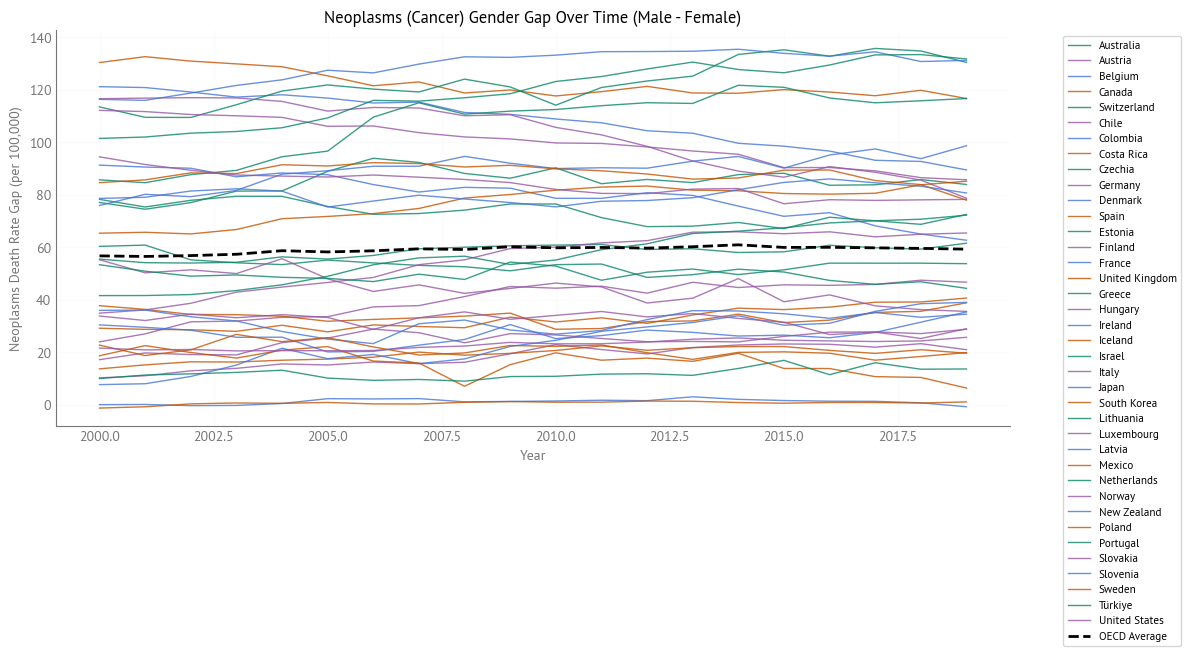

In [76]:
fig, ax = plot_gap_timeseries(
    neoplasms_temporal.reset_index(),
    'Gap_Neoplasms',
    title='Neoplasms (Cancer) Gender Gap Over Time (Male - Female)',
    ylabel='Neoplasms Death Rate Gap (per 100,000)'
)
plt.savefig('jb/figs/neoplasms_gap_timeseries_all.png', dpi=150, bbox_inches='tight')
plt.show()

#### Gaps for Selected Countries

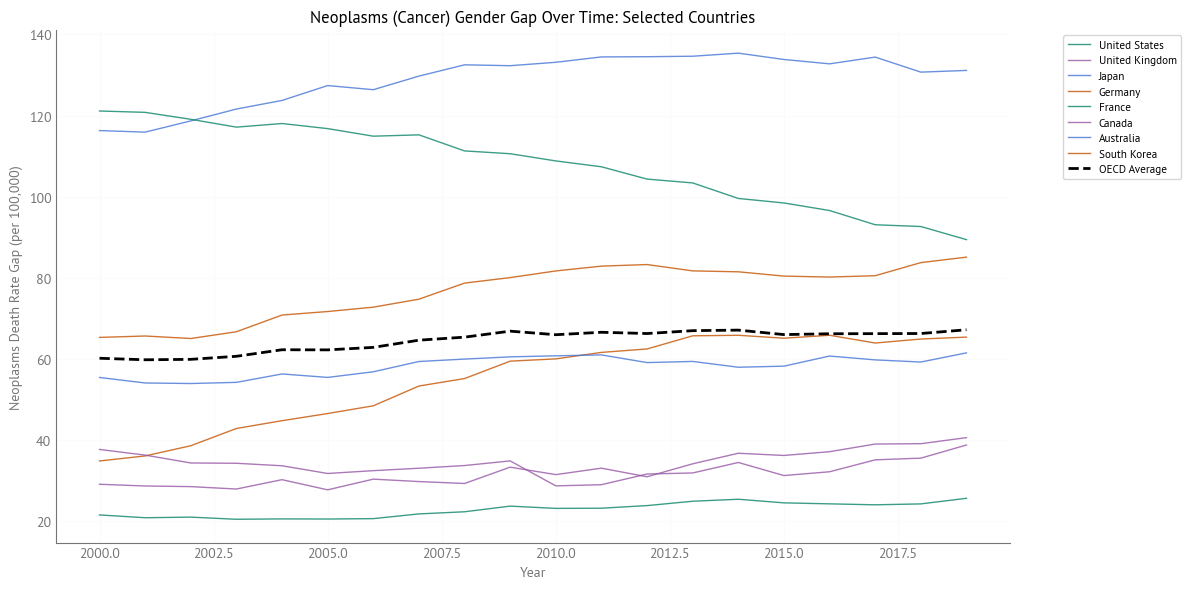

In [77]:
fig, ax = plot_gap_timeseries(
    neoplasms_temporal.reset_index(),
    'Gap_Neoplasms',
    countries=selected_countries,
    title='Neoplasms (Cancer) Gender Gap Over Time: Selected Countries',
    ylabel='Neoplasms Death Rate Gap (per 100,000)'
)
plt.savefig('jb/figs/neoplasms_gap_timeseries_selected.png', dpi=150, bbox_inches='tight')
plt.show()

### Unintentional Injuries

#### Rates for All Countries

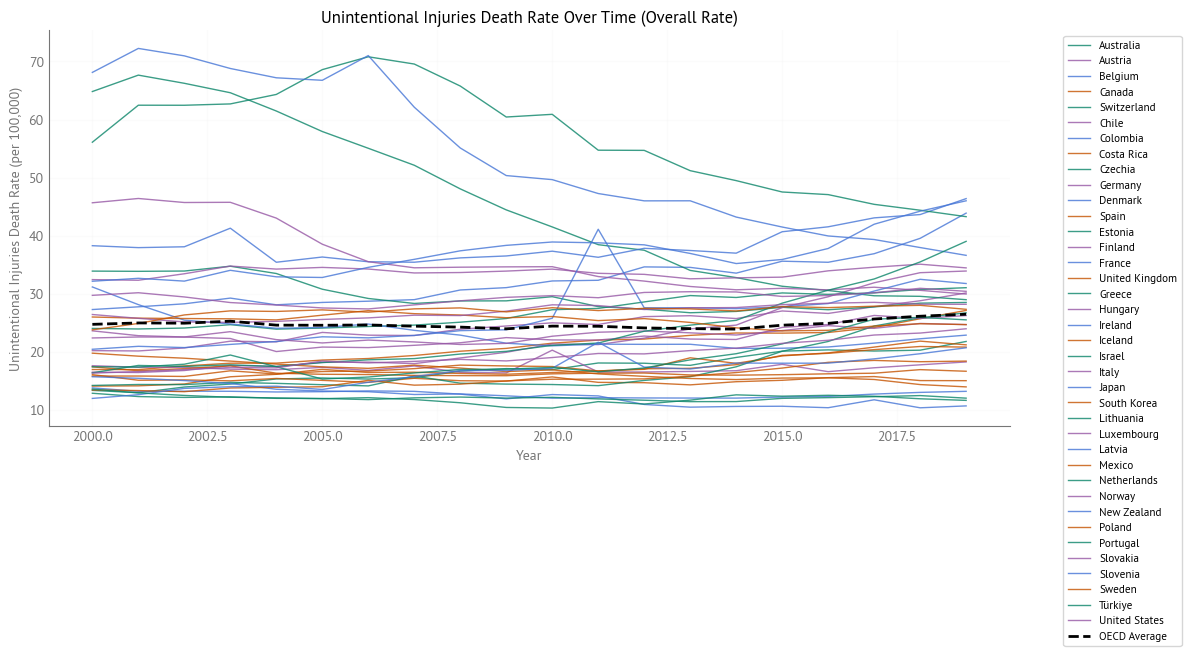

In [78]:
fig, ax = plot_rate_timeseries(
    unintentional_injuries_temporal.reset_index(),
    'Mid_UnintentionalInjury',
    title='Unintentional Injuries Death Rate Over Time (Overall Rate)',
    ylabel='Unintentional Injuries Death Rate (per 100,000)'
)
plt.savefig('jb/figs/unintentional_injury_rate_timeseries_all.png', dpi=150, bbox_inches='tight')
plt.show()

#### Rates for Selected Countries

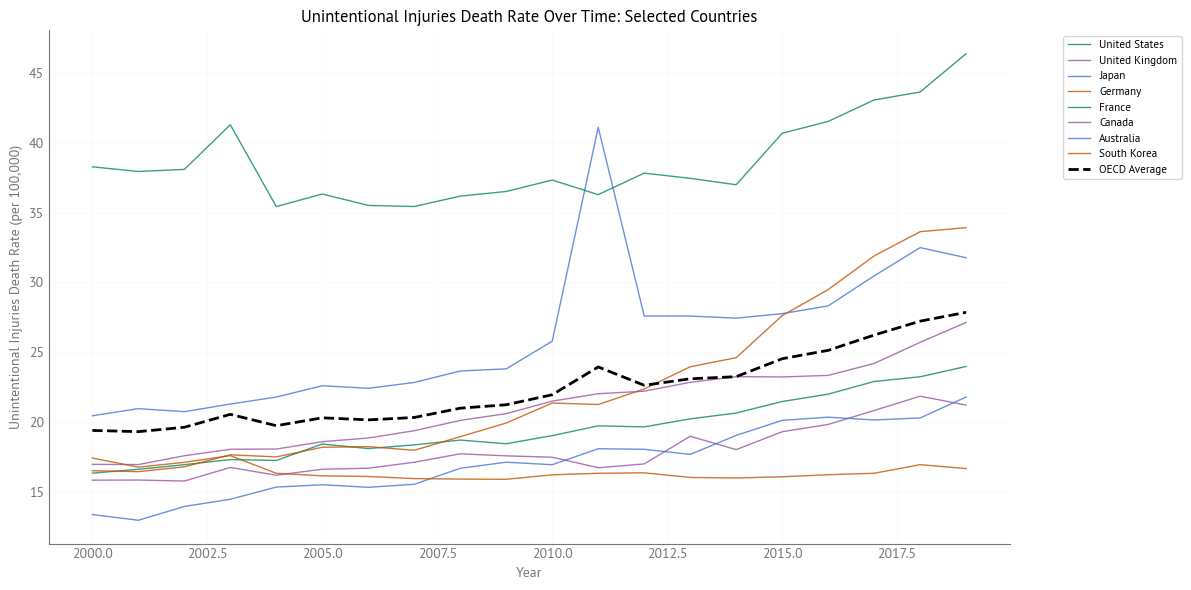

In [79]:
fig, ax = plot_rate_timeseries(
    unintentional_injuries_temporal.reset_index(),
    'Mid_UnintentionalInjury',
    countries=selected_countries,
    title='Unintentional Injuries Death Rate Over Time: Selected Countries',
    ylabel='Unintentional Injuries Death Rate (per 100,000)'
)
plt.savefig('jb/figs/unintentional_injury_rate_timeseries_selected.png', dpi=150, bbox_inches='tight')
plt.show()

#### Gaps for All Countries

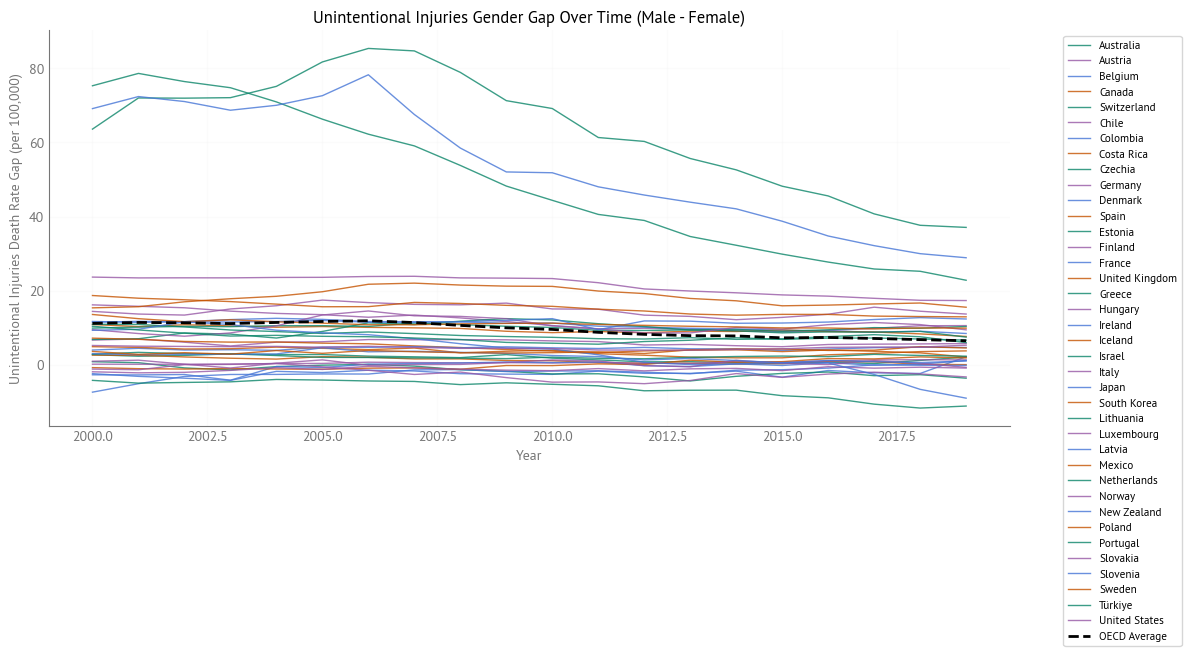

In [80]:
fig, ax = plot_gap_timeseries(
    unintentional_injuries_temporal.reset_index(),
    'Gap_UnintentionalInjury',
    title='Unintentional Injuries Gender Gap Over Time (Male - Female)',
    ylabel='Unintentional Injuries Death Rate Gap (per 100,000)'
)
plt.savefig('jb/figs/unintentional_injury_gap_timeseries_all.png', dpi=150, bbox_inches='tight')
plt.show()

#### Gaps for Selected Countries

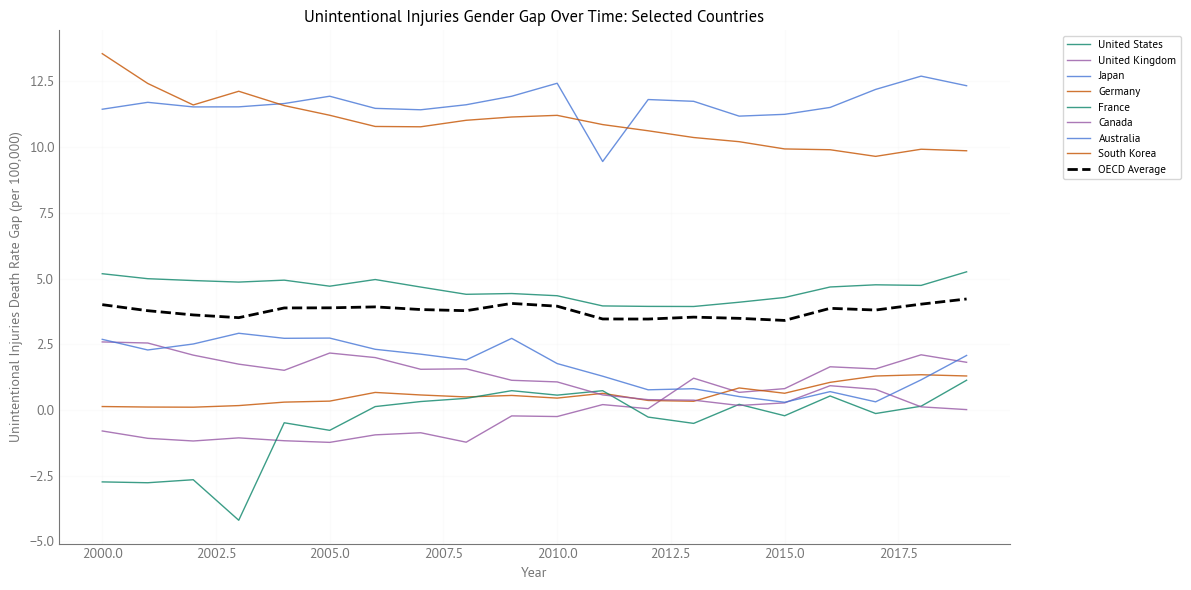

In [81]:
fig, ax = plot_gap_timeseries(
    unintentional_injuries_temporal.reset_index(),
    'Gap_UnintentionalInjury',
    countries=selected_countries,
    title='Unintentional Injuries Gender Gap Over Time: Selected Countries',
    ylabel='Unintentional Injuries Death Rate Gap (per 100,000)'
)
plt.savefig('jb/figs/unintentional_injury_gap_timeseries_selected.png', dpi=150, bbox_inches='tight')
plt.show()

### Diabetes Type 2

#### Rates for All Countries

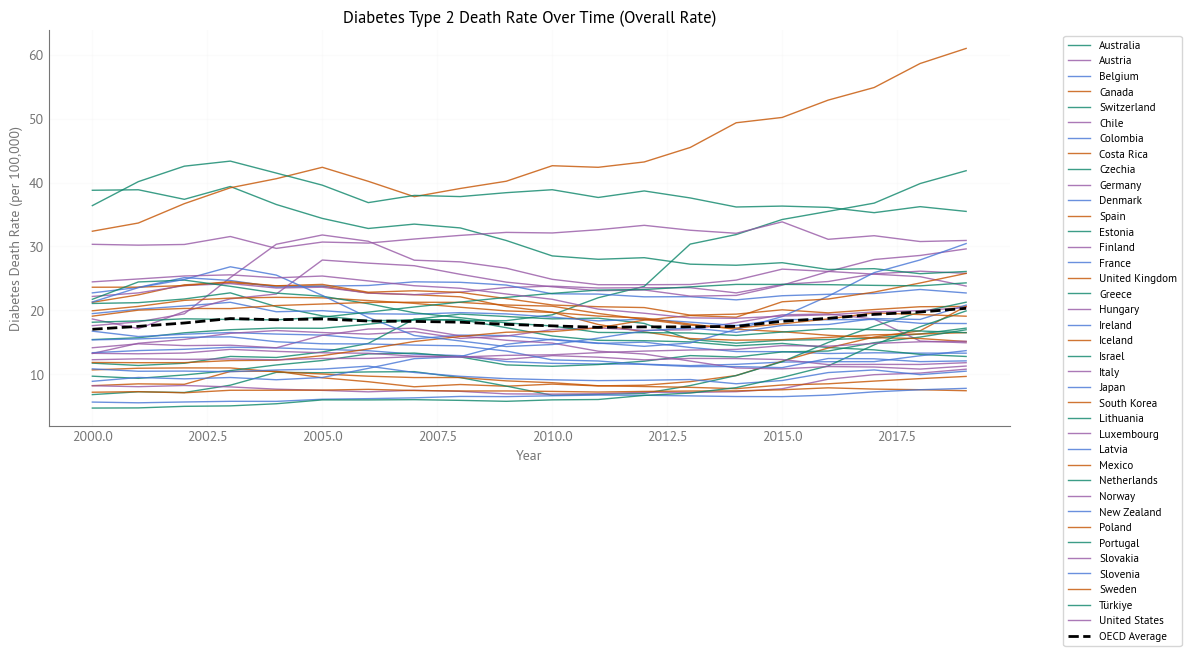

In [82]:
fig, ax = plot_rate_timeseries(
    diabetes_temporal.reset_index(),
    'Mid_Diabetes',
    title='Diabetes Type 2 Death Rate Over Time (Overall Rate)',
    ylabel='Diabetes Death Rate (per 100,000)'
)
plt.savefig('jb/figs/diabetes_rate_timeseries_all.png', dpi=150, bbox_inches='tight')
plt.show()

#### Rates for Selected Countries

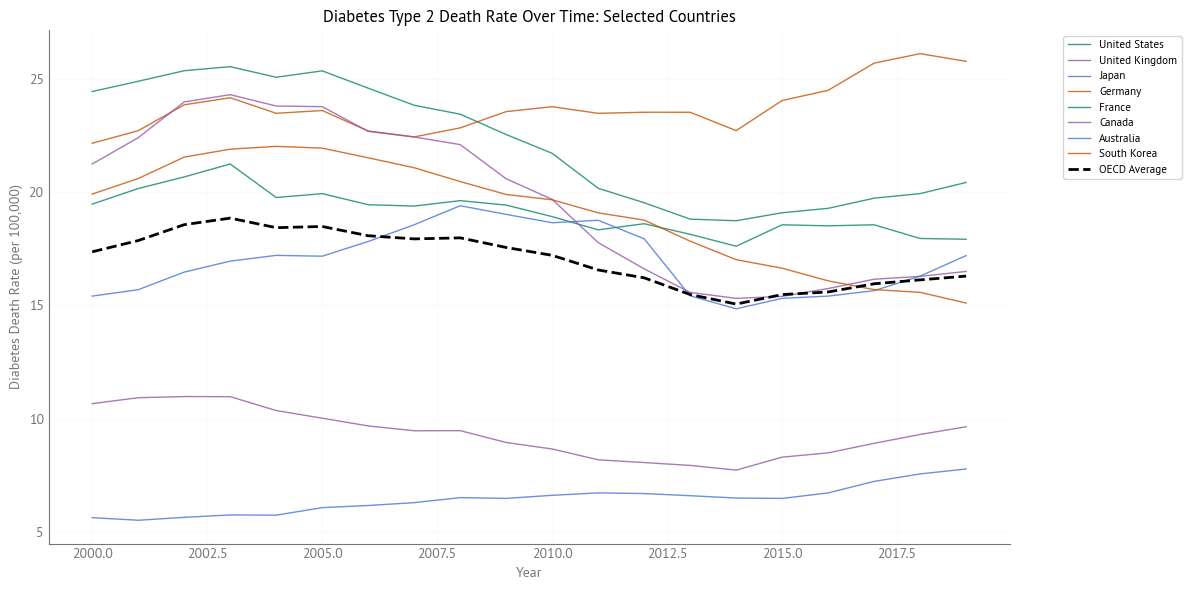

In [83]:
fig, ax = plot_rate_timeseries(
    diabetes_temporal.reset_index(),
    'Mid_Diabetes',
    countries=selected_countries,
    title='Diabetes Type 2 Death Rate Over Time: Selected Countries',
    ylabel='Diabetes Death Rate (per 100,000)'
)
plt.savefig('jb/figs/diabetes_rate_timeseries_selected.png', dpi=150, bbox_inches='tight')
plt.show()

#### Gaps for All Countries

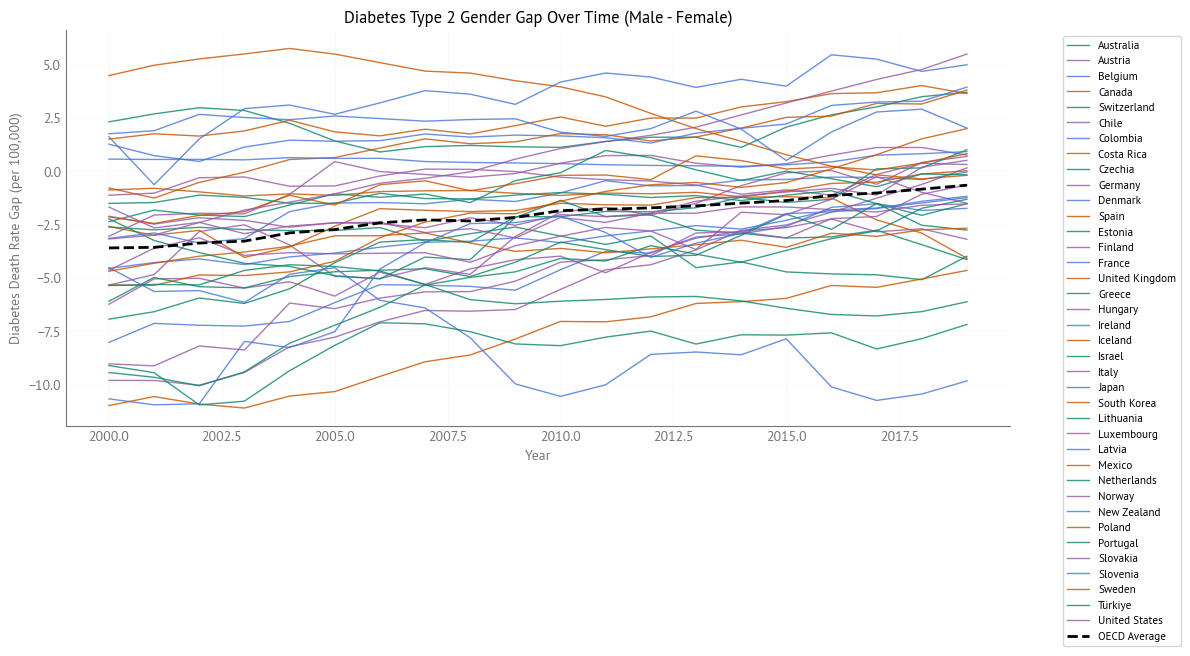

In [84]:
fig, ax = plot_gap_timeseries(
    diabetes_temporal.reset_index(),
    'Gap_Diabetes',
    title='Diabetes Type 2 Gender Gap Over Time (Male - Female)',
    ylabel='Diabetes Death Rate Gap (per 100,000)'
)
plt.savefig('jb/figs/diabetes_gap_timeseries_all.png', dpi=150, bbox_inches='tight')
plt.show()

#### Gaps for Selected Countries

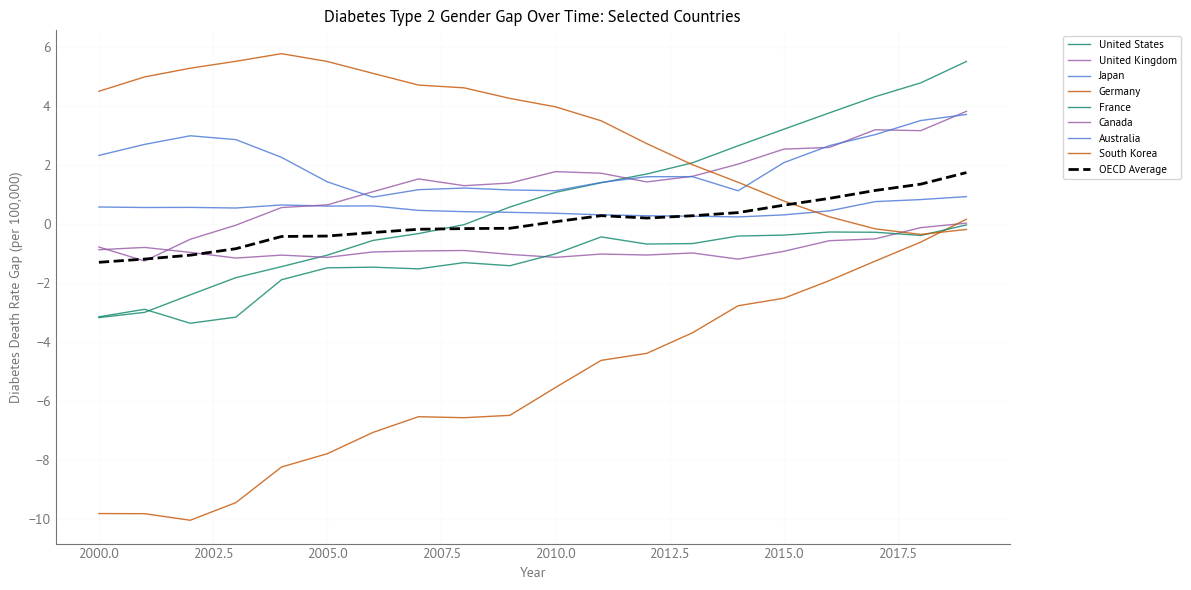

In [85]:
fig, ax = plot_gap_timeseries(
    diabetes_temporal.reset_index(),
    'Gap_Diabetes',
    countries=selected_countries,
    title='Diabetes Type 2 Gender Gap Over Time: Selected Countries',
    ylabel='Diabetes Death Rate Gap (per 100,000)'
)
plt.savefig('jb/figs/diabetes_gap_timeseries_selected.png', dpi=150, bbox_inches='tight')
plt.show()